# **Probability of default (PD) modeling**

This notebook outlines a general methodology for selecting features for a Probability of Default (PD) model and for determining the most appropriate categorical groupings for those features. We work with the dataset that has already been cleaned and preprocessed in the earlier steps.

Regulatory guidelines require PD models to be explainable and interpretable, which makes a credit scorecard approach particularly suitable. To build such a model, we rely on categorical variables as well as binned versions of continuous variables, where each category contributes a specific increase or decrease to the overall credit score.

Because several variables in the dataset exhibit high cardinality, it is important to analyze how individual categories relate to the target variable. This allows us to merge or re-group categories when appropriate, simplifying the model and improving interpretability without losing predictive signal.

## **Base imports**

In [ ]:
import sys
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn import __version__ as sklearn_version
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, average_precision_score
from sklearn.metrics import roc_curve, auc

from statsmodels.api import Logit

from pandas import Interval

from datetime import datetime

In [ ]:
%matplotlib inline
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [ ]:
print(f'Python {sys.version.split()[0]}')
print(f'pandas=={pd.__version__}')
print(f'numpy=={np.__version__}')
print(f'sklearn=={sklearn_version}')
print(f'matplotlib=={matplotlib.__version__}')
print(f'seaborn=={sns.__version__}')
print(f'statsmodels=={sm.__version__}')

Python 3.12.12
pandas==2.2.2
numpy==2.0.2
sklearn==1.6.1
matplotlib==3.10.0
seaborn==0.13.2
statsmodels==0.14.5


## **Loading the preprocessed dataset**

In [ ]:
df = pd.read_csv('processed-data/loan_data_processed.csv')
df.head()

,id,member_id,loan_amnt,funded_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,verification_status,initial_list_status,inq_last_6mths,open_acc,pub_rec,total_acc,acc_now_delinq,total_rev_hi_lim,recoveries,total_rec_prncp,months_since_issue_date,months_since_earliest_cr_line
0,1077501,1296599,5000.0,5000.0,36,10.65,162.87,B,10.0,RENT,24000.0,2011-12-01,Fully Paid,credit_card,AZ,27.65,0.0,1985-01-01,Verified,f,1.0,3.0,0.0,9.0,0.0,NaN,0.00,5000.00,72.010512,394.940867
1,1077430,1314167,2500.0,2500.0,60,15.27,59.83,C,0.0,RENT,30000.0,2011-12-01,Charged Off,car,GA,1.00,0.0,1999-04-01,Source Verified,f,5.0,3.0,0.0,4.0,0.0,NaN,117.08,456.46,72.010512,224.014455
2,1077175,1313524,2400.0,2400.0,36,15.96,84.33,C,10.0,RENT,12252.0,2011-12-01,Fully Paid,small_business,IL,8.72,0.0,2001-11-01,Not Verified,f,2.0,2.0,0.0,10.0,0.0,NaN,0.00,2400.00,72.010512,192.969777
3,1076863,1277178,10000.0,10000.0,36,13.49,339.31,C,10.0,RENT,49200.0,2011-12-01,Fully Paid,other,CA,20.00,0.0,1996-02-01,Source Verified,f,1.0,10.0,0.0,37.0,0.0,NaN,0.00,10000.00,72.010512,261.957950
4,1075358,1311748,3000.0,3000.0,60,12.69,67.79,B,1.0,RENT,80000.0,2011-12-01,Current,other,OR,17.94,0.0,1996-01-01,Source Verified,f,0.0,15.0,0.0,38.0,0.0,NaN,0.00,2233.10,72.010512,262.976347


## **Defining the target variable**

We begin by constructing the target variable for the PD model. The loan_status field contains several possible outcomes, but for PD estimation we must convert these statuses into a binary default indicator, where:

- 0 = non-default

- 1 = default

To do this, we identify the loan statuses that clearly represent credit events consistent with default:

- *Charged Off*

- *Late (31–120 days)*

- *Default*

- *Does not meet the credit policy. Status: Charged Off*

We then create a new variable, default, which assigns a value of 1 to observations falling into any of these categories and 0 otherwise. After encoding, the dataset shows approximately 10.9% defaulted loans and 89.1% non-defaulted loans, which aligns with typical credit-risk distributions.

In [ ]:
df["loan_status"].value_counts()

,count
loan_status,
Current,224226
Fully Paid,184739
Charged Off,42475
Late (31-120 days),6900
In Grace Period,3146
Does not meet the credit policy. Status:Fully Paid,1988
Late (16-30 days),1218
Default,832
Does not meet the credit policy. Status:Charged Off,761


In [ ]:
default_categories = [
    "Charged Off",
    "Late (31-120 days)",
    "Default",
    "Does not meet the credit policy. Status:Charged Off"
]

target_variable = "default"

df[target_variable] = df["loan_status"].isin(default_categories).astype(float)
(df[target_variable].value_counts() / len(df)).apply(lambda x: f"{100*x:.2f}%")

,count
default,
0.0,89.07%
1.0,10.93%


## **Creating WoE an IV functions**

- **Weight of evidence**

Weight of Evidence (WoE) measures how well a categorical (or binned numerical) variable separates the good (non-default) and bad (default) populations. It is computed for each category using the formula:

**WoE = ln( (Proportion of Goods in Category) / (Proportion of Bads in Category) )**

A WoE value far from zero indicates that the category contributes strongly to differentiating between default and non-default cases; values close to zero indicate weak separation.

When analyzing discrete variables with WoE, it is important to inspect both WoE values and category proportions. Categories with very few observations may need to be combined to avoid instability, while categories with strong separation should remain distinct.

Information Value (IV) summarizes the overall predictive strength of a feature. It aggregates the contribution of each category using:

**IV = Σ (Proportion_Good_i – Proportion_Bad_i) * WoE_i**

V is widely used for feature selection. Typical interpretation:

- < 0.02	- No predictive power
- 0.02 – 0.10	- Weak predictive power
- 0.10 – 0.30	- Medium predictive power
- 0.30 – 0.50	- Strong predictive power
- greater than 0.50	- Suspiciously strong (often data leakage)

Creating a function to calculate WoE and IV for any variable greatly simplifies the scorecard-building workflow. Likewise, adding a function to visualize WoE values across categories helps identify which categories should be combined or kept separate.

In [ ]:
def compute_woe(
    df: pd.DataFrame,
    id_column_name: str,
    feature_column_name: str,
    target_column_name: str,
    sort_by_woe: bool = True,
    eps: float = 0.5   # smoothing to avoid division by zero
) -> pd.DataFrame:

    # CONTINGENCY TABLE
    matrix = pd.pivot_table(
        data=df,
        index=feature_column_name,
        columns=target_column_name,
        values=id_column_name,
        aggfunc="count"
    ).fillna(0)

    # Rename columns to standard Good / Bad
    matrix.columns = ["Good", "Bad"]

    # Apply smoothing
    matrix["Good"] += eps
    matrix["Bad"] += eps

    # TOTAL OBSERVATIONS
    matrix["Total"] = matrix.sum(axis=1)

    # PROPORTIONS
    matrix["% Good"] = matrix["Good"] / matrix["Good"].sum()
    matrix["% Bad"] = matrix["Bad"] / matrix["Bad"].sum()

    # WoE
    matrix["WoE"] = np.log(matrix["% Good"] / matrix["% Bad"])

    # IV (per category and total)
    matrix["IV_individual"] = (matrix["% Good"] - matrix["% Bad"]) * matrix["WoE"]
    matrix["IV_total"] = matrix["IV_individual"].sum()

    # SORT
    if sort_by_woe:
        matrix = matrix.sort_values(by="WoE")

    return matrix

In [ ]:
def plot_woe_by_category(
    df: pd.DataFrame,
    rotate: bool = False
) -> None:
    woe_column = "WoE"
    _, ax = plt.subplots(1, 1, figsize=(10, 5))
    ax.plot(df.index, df[woe_column], "o--", color="black")
    ax.set_xlabel(df.index.name.capitalize())
    if rotate:
        plt.xticks(rotation=90)
    ax.set_ylabel(woe_column)
    plt.grid(alpha=0.3, linestyle="--")
    plt.show()

## **Train / test split**

We split the dataset into training and test sets to ensure proper model validation and prevent any form of data leakage.

In [ ]:
selected_cols = [
    "id", "member_id", "loan_amnt", "funded_amnt", "term", "int_rate", "installment", "grade", "emp_length",
    "home_ownership", "annual_inc", "issue_d", "loan_status", "purpose", "addr_state", "dti", "delinq_2yrs",
    "earliest_cr_line", "verification_status", "initial_list_status", "inq_last_6mths", "open_acc", "pub_rec",
    "total_acc", "total_rev_hi_lim", "months_since_issue_date", "months_since_earliest_cr_line", "default"
]

df = df.loc[:, selected_cols]

In [ ]:
df["earliest_cr_line"].isnull().sum()

np.int64(29)

In [ ]:
df["earliest_cr_line"] = df["earliest_cr_line"].fillna(df["issue_d"])

In [ ]:
df_train, df_test = train_test_split(df, test_size=0.20, random_state=99, stratify=df[target_variable])

## **Analyzing categorical variables**

Now we focus on the categorical variables and use WoE analysis to determine the most appropriate categories for each feature.

The variables under analysis are:

- `grade`

- `home_ownership`

- `addr_state`

- `verification_status`

- `purpose`

- `initial_list_status`

In [ ]:
df_train_mod = df_train.copy()
df_test_mod = df_test.copy()

In [ ]:
variable = "grade"

In [ ]:
print(f"{df_train_mod[variable].isnull().sum():,} missing rows!\n\n")
print(df_train_mod[variable].value_counts())

0 missing rows!


grade
B    109603
C    100372
D     61548
A     59796
E     28514
F     10502
G      2693
Name: count, dtype: int64


In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name=variable,
    target_column_name=target_variable,
)
woe_df

,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
grade,,,,,,,,
G,1960.5,733.5,2694.0,0.005901,0.017988,-1.114653,0.013473,0.290944
F,7960.5,2542.5,10503.0,0.023959,0.062351,-0.956436,0.036719,0.290944
E,22981.5,5533.5,28515.0,0.069168,0.135700,-0.673911,0.044837,0.290944
D,52076.5,9472.5,61549.0,0.156735,0.232297,-0.393459,0.029730,0.290944
C,88788.5,11584.5,100373.0,0.267228,0.284090,-0.061191,0.001032,0.290944
B,100983.5,8620.5,109604.0,0.303931,0.211403,0.363034,0.033591,0.290944
A,57506.5,2290.5,59797.0,0.173078,0.056171,1.125348,0.131562,0.290944


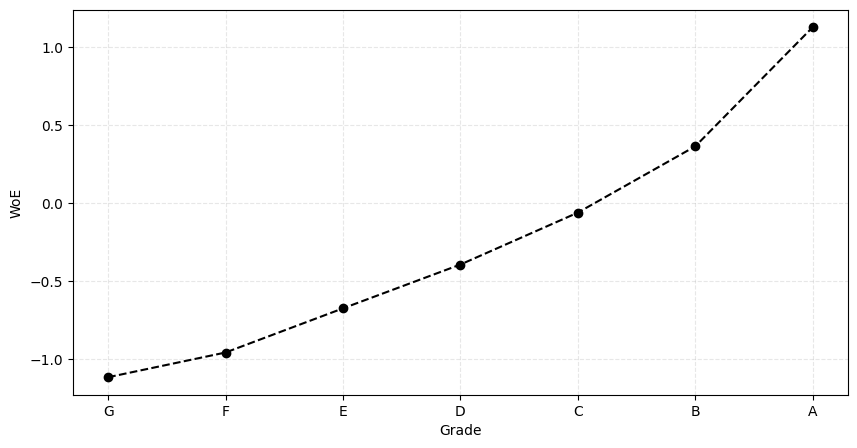

In [ ]:
plot_woe_by_category(woe_df)

Based on the WoE analysis above, we will retain the seven original categories (A through G). The WoE values increase monotonically from G to A, indicating that A represents the strongest credit quality (highest proportion of non-defaults) while G corresponds to the weakest (highest proportion of defaults).

In [ ]:
variable = "home_ownership"

In [ ]:
print(f"{df_train_mod[variable].isnull().sum():,} missing rows!\n\n")
print(df_train_mod[variable].value_counts())

0 missing rows!


home_ownership
MORTGAGE    188830
RENT        150642
OWN          33364
OTHER          152
NONE            39
ANY              1
Name: count, dtype: int64


In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name=variable,
    target_column_name=target_variable,
)
woe_df

,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
home_ownership,,,,,,,,
ANY,1.5,0.5,2.0,0.000005,0.000012,-0.999178,0.000008,0.021518
OTHER,118.5,34.5,153.0,0.000357,0.000846,-0.863837,0.000423,0.021518
NONE,34.5,5.5,40.0,0.000104,0.000135,-0.261579,0.000008,0.021518
RENT,131658.5,18984.5,150643.0,0.396255,0.465569,-0.161202,0.011174,0.021518
OWN,29755.5,3609.5,33365.0,0.089556,0.088518,0.011654,0.000012,0.021518
MORTGAGE,170688.5,18142.5,188831.0,0.513724,0.444920,0.143792,0.009894,0.021518


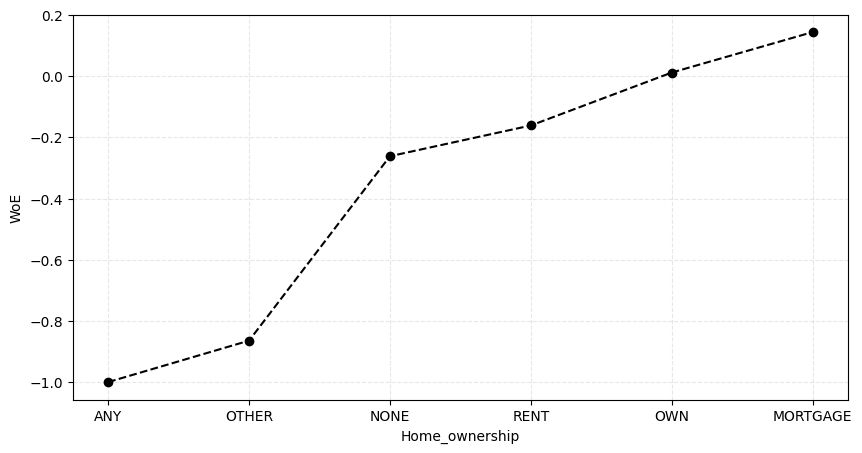

In [ ]:
plot_woe_by_category(woe_df)

From the WoE results above, we can see that the categories ANY, OTHER, and NONE have very few observations and contribute minimally to the overall information value (IV). Their meaning is also ambiguous, making them difficult to interpret from a risk perspective.

From a conservative risk-management standpoint, it is prudent to treat these small, unclear categories as high-risk, aligning them with the RENT category, which has a similarly negative WoE and represents lower credit quality. This approach ensures that we do not underestimate the risk associated with these observations.

The other categories — OWN and MORTGAGE — have larger populations and WoE values closer to zero or positive, indicating lower risk compared to RENT.

In [ ]:
print("Original train categories:", df_train_mod['home_ownership'].unique())

# Define the mapping - combine these into one category
category_mapping = {
    'OTHER': 'NONE_OTHER_RENT_ANY',
    'NONE': 'NONE_OTHER_RENT_ANY',
    'ANY': 'NONE_OTHER_RENT_ANY',
    'RENT': 'NONE_OTHER_RENT_ANY',  # Keep RENT as part of the combined group
    'OWN': 'OWN',              # Keep as is
    'MORTGAGE': 'MORTGAGE'     # Keep as is
}

# Apply the mapping to the home_ownership column
df_train_mod['home_ownership'] = df_train_mod['home_ownership'].replace(category_mapping)


print("New train categories:", df_train_mod['home_ownership'].unique())
print("Value counts:")
print(df_train_mod['home_ownership'].value_counts())

Original train categories: ['RENT' 'MORTGAGE' 'OWN' 'OTHER' 'NONE' 'ANY']
New train categories: ['NONE_OTHER_RENT_ANY' 'MORTGAGE' 'OWN']
Value counts:
home_ownership
MORTGAGE               188830
NONE_OTHER_RENT_ANY    150834
OWN                     33364
Name: count, dtype: int64


In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name=variable,
    target_column_name=target_variable,
)
woe_df

,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
home_ownership,,,,,,,,
NONE_OTHER_RENT_ANY,131811.5,19023.5,150835.0,0.396717,0.466542,-0.162125,0.011320,0.021222
OWN,29755.5,3609.5,33365.0,0.089556,0.088521,0.011622,0.000012,0.021222
MORTGAGE,170688.5,18142.5,188831.0,0.513727,0.444936,0.143760,0.009889,0.021222


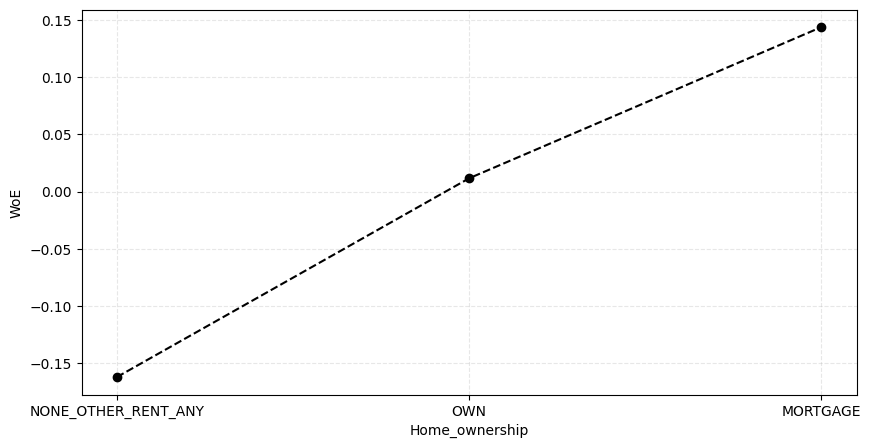

In [ ]:
plot_woe_by_category(woe_df)

In [ ]:
print("Original test categories:", df_test_mod['home_ownership'].unique())

df_test_mod['home_ownership'] = df_test_mod['home_ownership'].replace(category_mapping)

print("New test categories:", df_test_mod['home_ownership'].unique())
print("Value counts:")
print(df_test_mod['home_ownership'].value_counts())

Original test categories: ['RENT' 'MORTGAGE' 'OWN' 'OTHER' 'NONE']
New test categories: ['NONE_OTHER_RENT_ANY' 'MORTGAGE' 'OWN']
Value counts:
home_ownership
MORTGAGE               47045
NONE_OTHER_RENT_ANY    37872
OWN                     8340
Name: count, dtype: int64


In [ ]:
variable = "addr_state"

In [ ]:
print(f"{df_train_mod[variable].isnull().sum():,} missing rows!\n\n")
print(df_train_mod[variable].unique())
print(df_train_mod[variable].nunique())

0 missing rows!


['CA' 'TX' 'IL' 'NY' 'PA' 'FL' 'MD' 'KS' 'AL' 'WA' 'AZ' 'NC' 'SC' 'GA'
 'IN' 'NJ' 'OR' 'MI' 'NV' 'OK' 'VA' 'WY' 'CT' 'NM' 'OH' 'MO' 'TN' 'CO'
 'MA' 'WV' 'NH' 'LA' 'DE' 'KY' 'UT' 'VT' 'AR' 'WI' 'HI' 'MN' 'DC' 'MT'
 'RI' 'SD' 'MS' 'AK' 'NE' 'ID' 'ME' 'IA']
50


From the dataset, we expect 50 states plus DC. North Dakota (ND) is missing, so we will include it in the highest-risk category.

In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name=variable,
    target_column_name=target_variable,
)
woe_df

,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
addr_state,,,,,,,,
NE,6.5,7.5,14.0,0.000020,0.000184,-2.240418,3.680249e-04,0.013224
IA,9.5,2.5,12.0,0.000029,0.000061,-0.762316,2.491675e-05,0.013224
ID,8.5,1.5,10.0,0.000026,0.000037,-0.362716,4.056872e-06,0.013224
NV,4510.5,739.5,5250.0,0.013574,0.018125,-0.289128,1.315826e-03,0.013224
HI,1703.5,253.5,1957.0,0.005127,0.006213,-0.192241,2.089029e-04,0.013224
FL,22140.5,3177.5,25318.0,0.066632,0.077882,-0.156004,1.754971e-03,0.013224
ME,3.5,0.5,4.0,0.000011,0.000012,-0.151407,2.607060e-07,0.013224
AL,4119.5,570.5,4690.0,0.012398,0.013983,-0.120343,1.908012e-04,0.013224
OK,2894.5,395.5,3290.0,0.008711,0.009694,-0.106901,1.050631e-04,0.013224


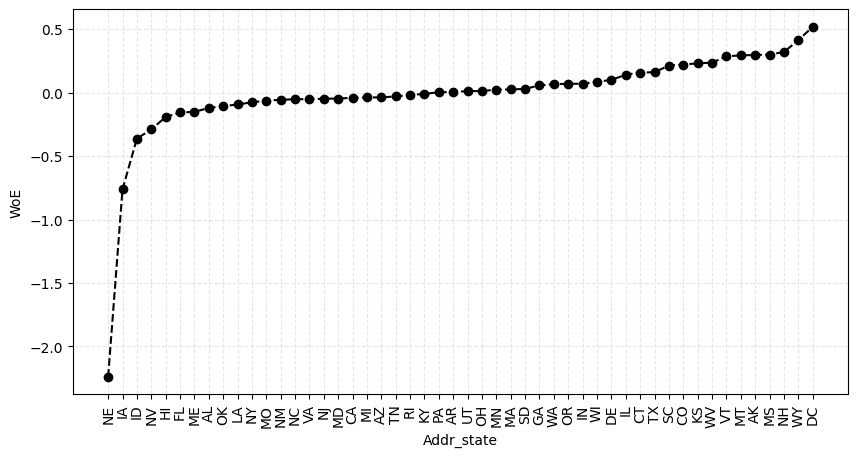

In [ ]:
plot_woe_by_category(woe_df, rotate=True)

The WoE visualization can be misleading due to scale, and the last three categories (ME, NE, IA) have very few observations and are not representative, so we will temporarily exclude them from separate grouping.

In [ ]:
states_to_remove = ['NE', 'IA', 'ID', 'ME']
woe_df_filtered = woe_df[~woe_df.index.isin(states_to_remove)]
woe_df_filtered

,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
addr_state,,,,,,,,
NV,4510.5,739.5,5250.0,0.013574,0.018125,-0.289128,1.315826e-03,0.013224
HI,1703.5,253.5,1957.0,0.005127,0.006213,-0.192241,2.089029e-04,0.013224
FL,22140.5,3177.5,25318.0,0.066632,0.077882,-0.156004,1.754971e-03,0.013224
AL,4119.5,570.5,4690.0,0.012398,0.013983,-0.120343,1.908012e-04,0.013224
OK,2894.5,395.5,3290.0,0.008711,0.009694,-0.106901,1.050631e-04,0.013224
LA,3894.5,524.5,4419.0,0.011721,0.012856,-0.092442,1.049344e-04,0.013224
NY,28426.5,3767.5,32194.0,0.085550,0.092343,-0.076407,5.190233e-04,0.013224
MO,5330.5,696.5,6027.0,0.016042,0.017071,-0.062185,6.400411e-05,0.013224
NM,1874.5,243.5,2118.0,0.005641,0.005968,-0.056337,1.841885e-05,0.013224


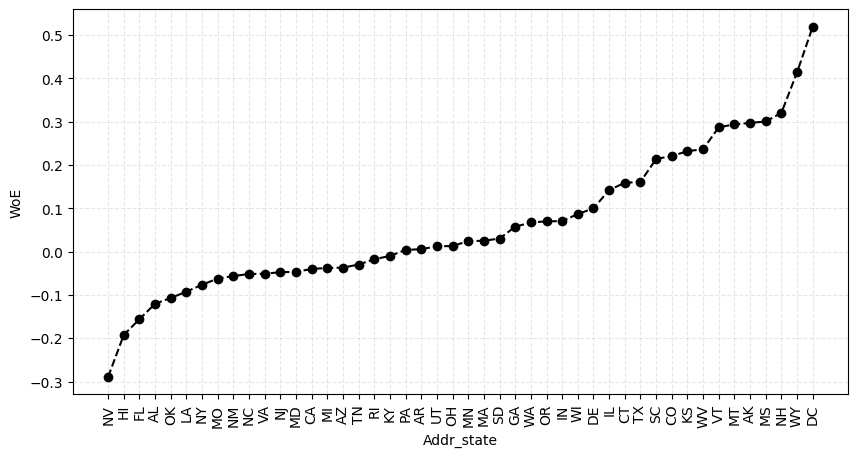

In [ ]:
plot_woe_by_category(woe_df_filtered, rotate=True)

Based on WoE analysis and representativeness, we propose the following grouping:

NV, ND, ME, NE, IA → combined into a single high-risk category

HI → separate category (lower WoE than FL)

FL → separate category (stands out with large population)

AL, OK, LA → grouped together

NY → separate category (distinct WoE despite similarity with neighbors)

MO → separate category

MD, NJ, VA, NC, NM → grouped together

CA → separate category (stands out)

TN, AZ, MI → grouped together

KY, RI, ID → grouped together

PA, AR, OH, UT → grouped together

MN, MA, SD → grouped together

IN, OR, WA, GA → grouped together

WI, DE → grouped together (DE not representative)

IL, TX, CT → kept as separate categories (TX stands out)

WV, KS, CO, SC → grouped together

MS, AK, MT, VT → grouped together

NH, WY, DC → grouped together (edge-of-spectrum, not representative)

This grouping balances representativeness, WoE separation, and risk conservatism, ensuring that small or ambiguous states are handled cautiously while significant states are retained as their own categories.

In [ ]:
print("Original train categories:", df_train_mod['addr_state'].unique())

# Define the mapping
category_mapping = {
    "NV_ND_ME_NE_IA": ["NV", "ND", "ME", "NE", "IA"],
    "HI": ["HI"],
    "FL": ["FL"],
    "AL_OK_LA": ["AL", "OK", "LA"],
    "NY": ["NY"],
    "MO": ["MO"],
    "MD_NJ_VA_NC_NM": ["NJ", "VA", "NC", "NM", "MD"],
    "CA": ["CA"],
    "TN_AZ_MI": ["TN", "AZ", "MI"],
    "KY_RI_ID": ["KY", "RI", "ID"],
    "PA_AR_OH_UT": ["PA", "AR", "OH", "UT"],
    "MN_MA_SD": ["MN", "MA", "SD"],
    "IN_OR_WA_GA": ["IN", "OR", "WA", "GA"],
    "WI_DE": ["WI", "DE"],
    "IL": ["IL"],
    "TX": ["TX"],
    "CT": ["CT"],
    "WV_KS_CO_SC": ["WV", "KS", "CO", "SC"],
    "MS_AK_MT_VT": ["MS", "AK", "MT", "VT"],
    "NH_WY_DC": ["NH", "WY", "DC"]
}

# Create flattened mapping for .replace()
flat_mapping = {}
for new_group, old_states in category_mapping.items():
    for state in old_states:
        flat_mapping[state] = new_group

print(f"Created {len(flat_mapping)} state-to-group mappings")

# Apply the mapping
df_train_mod['addr_state'] = df_train_mod['addr_state'].replace(flat_mapping)

print("New train categories:", df_train_mod['addr_state'].unique())
print("Number of new categories:", df_train_mod['addr_state'].nunique())
print("\nValue counts:")
print(df_train_mod['addr_state'].value_counts())

Original train categories: ['CA' 'TX' 'IL' 'NY' 'PA' 'FL' 'MD' 'KS' 'AL' 'WA' 'AZ' 'NC' 'SC' 'GA'
 'IN' 'NJ' 'OR' 'MI' 'NV' 'OK' 'VA' 'WY' 'CT' 'NM' 'OH' 'MO' 'TN' 'CO'
 'MA' 'WV' 'NH' 'LA' 'DE' 'KY' 'UT' 'VT' 'AR' 'WI' 'HI' 'MN' 'DC' 'MT'
 'RI' 'SD' 'MS' 'AK' 'NE' 'ID' 'ME' 'IA']
Created 51 state-to-group mappings
New train categories: ['CA' 'TX' 'IL' 'NY' 'PA_AR_OH_UT' 'FL' 'MD_NJ_VA_NC_NM' 'WV_KS_CO_SC'
 'AL_OK_LA' 'IN_OR_WA_GA' 'TN_AZ_MI' 'NV_ND_ME_NE_IA' 'NH_WY_DC' 'CT' 'MO'
 'MN_MA_SD' 'WI_DE' 'KY_RI_ID' 'MS_AK_MT_VT' 'HI']
Number of new categories: 20

Value counts:
addr_state
CA                57022
MD_NJ_VA_NC_NM    46836
NY                32193
PA_AR_OH_UT       31071
IN_OR_WA_GA       30371
TX                29150
FL                25317
TN_AZ_MI          22431
WV_KS_CO_SC       17445
MN_MA_SD          16095
IL                14944
AL_OK_LA          12396
MO                 6026
CT                 5795
WI_DE              5792
NV_ND_ME_NE_IA     5276
KY_RI_ID           5244
M

In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name=variable,
    target_column_name=target_variable,
)
woe_df

,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
addr_state,,,,,,,,
NV_ND_ME_NE_IA,4528.5,748.5,5277.0,0.013629,0.018353,-0.297565,0.001406,0.012892
HI,1703.5,253.5,1957.0,0.005127,0.006216,-0.192564,0.000210,0.012892
FL,22140.5,3177.5,25318.0,0.066635,0.077910,-0.156326,0.001763,0.012892
AL_OK_LA,10907.5,1489.5,12397.0,0.032828,0.036522,-0.106630,0.000394,0.012892
NY,28426.5,3767.5,32194.0,0.085554,0.092377,-0.076730,0.000524,0.012892
MO,5330.5,696.5,6027.0,0.016043,0.017078,-0.062507,0.000065,0.012892
MD_NJ_VA_NC_NM,41486.5,5350.5,46837.0,0.124860,0.131191,-0.049462,0.000313,0.012892
CA,50561.5,6461.5,57023.0,0.152173,0.158432,-0.040311,0.000252,0.012892
TN_AZ_MI,19900.5,2531.5,22432.0,0.059894,0.062071,-0.035707,0.000078,0.012892


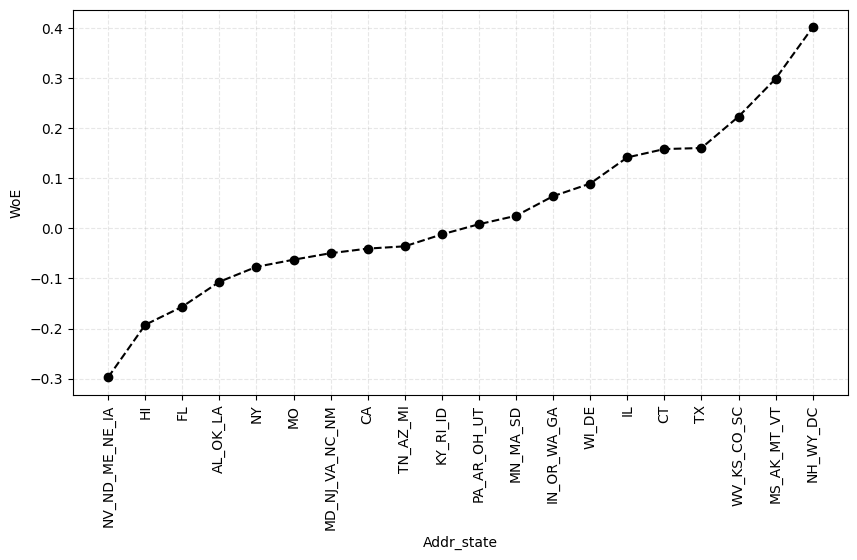

In [ ]:
plot_woe_by_category(woe_df, rotate=True)

In [ ]:
print("Original test categories:", df_test_mod['addr_state'].unique())

df_test_mod['addr_state'] = df_test_mod['addr_state'].replace(flat_mapping)

print("New test categories:", df_test_mod['addr_state'].unique())
print("Value counts:")
print(df_test_mod['addr_state'].value_counts())

Original test categories: ['RI' 'MD' 'VA' 'FL' 'AL' 'NY' 'OH' 'TX' 'GA' 'OR' 'CA' 'MA' 'NJ' 'HI'
 'NC' 'PA' 'AZ' 'TN' 'IL' 'KY' 'UT' 'MN' 'LA' 'OK' 'CT' 'KS' 'WA' 'SC'
 'WI' 'MO' 'AK' 'SD' 'MS' 'IN' 'CO' 'MI' 'AR' 'WV' 'DE' 'NM' 'NV' 'NH'
 'VT' 'DC' 'MT' 'WY' 'ID' 'IA' 'NE' 'ME']
New test categories: ['KY_RI_ID' 'MD_NJ_VA_NC_NM' 'FL' 'AL_OK_LA' 'NY' 'PA_AR_OH_UT' 'TX'
 'IN_OR_WA_GA' 'CA' 'MN_MA_SD' 'HI' 'TN_AZ_MI' 'IL' 'CT' 'WV_KS_CO_SC'
 'WI_DE' 'MO' 'MS_AK_MT_VT' 'NV_ND_ME_NE_IA' 'NH_WY_DC']
Value counts:
addr_state
CA                14428
MD_NJ_VA_NC_NM    11691
NY                 8049
IN_OR_WA_GA        7595
PA_AR_OH_UT        7506
TX                 7289
FL                 6320
TN_AZ_MI           5814
WV_KS_CO_SC        4479
MN_MA_SD           4115
IL                 3668
AL_OK_LA           3063
MO                 1482
CT                 1409
WI_DE              1391
NV_ND_ME_NE_IA     1275
KY_RI_ID           1256
NH_WY_DC            959
MS_AK_MT_VT         937
HI                  

In [ ]:
variable = "verification_status"

In [ ]:
print(f"{df_train_mod[variable].isnull().sum():,} missing rows!\n\n")
print(df_train_mod[variable].value_counts())

0 missing rows!


verification_status
Verified           134457
Source Verified    119799
Not Verified       118772
Name: count, dtype: int64


In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name=variable,
    target_column_name=target_variable,
)
woe_df

,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
verification_status,,,,,,,,
Verified,117438.5,17019.5,134458.0,0.353458,0.417395,-0.166268,0.010631,0.018864
Source Verified,107329.5,12470.5,119800.0,0.323033,0.305833,0.054715,0.000941,0.018864
Not Verified,107487.5,11285.5,118773.0,0.323509,0.276772,0.156033,0.007293,0.018864


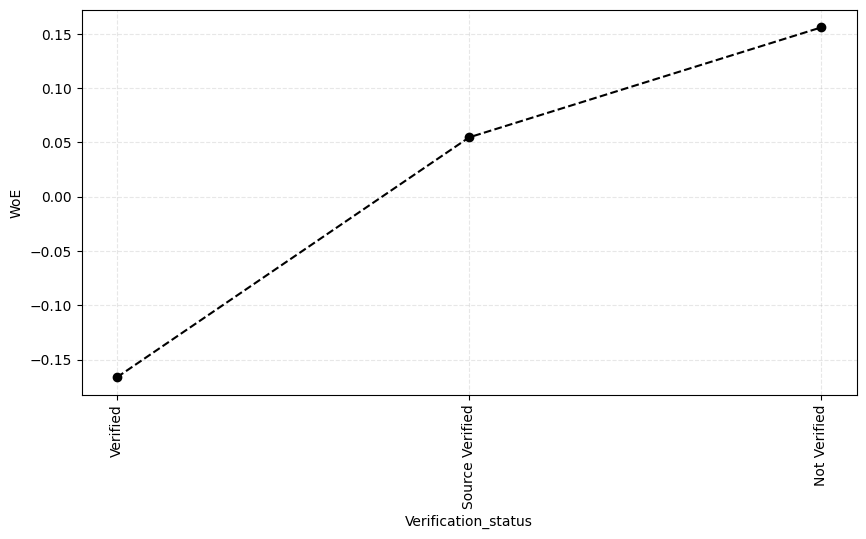

In [ ]:
plot_woe_by_category(woe_df, rotate=True)

From the WoE results above, we can see that the values increase almost monotonically. Therefore, no further adjustments are needed

In [ ]:
variable = "purpose"

In [ ]:
print(f"{df_train_mod[variable].isnull().sum():,} missing rows!\n\n")
print(df_train_mod[variable].value_counts())

0 missing rows!


purpose
debt_consolidation    219434
credit_card            83206
home_improvement       21215
other                  19049
major_purchase          7893
small_business          5619
car                     4316
medical                 3658
moving                  2359
vacation                1949
wedding                 1890
house                   1831
educational              323
renewable_energy         286
Name: count, dtype: int64


In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name=variable,
    target_column_name=target_variable,
)
woe_df

,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
purpose,,,,,,,,
small_business,4415.5,1204.5,5620.0,0.013289,0.029536,-0.798648,0.012975,0.036963
educational,256.5,67.5,324.0,0.000772,0.001655,-0.762703,0.000674,0.036963
renewable_energy,242.5,44.5,287.0,0.000730,0.001091,-0.402192,0.000145,0.036963
moving,1999.5,360.5,2360.0,0.006018,0.008840,-0.384544,0.001085,0.036963
house,1565.5,266.5,1832.0,0.004712,0.006535,-0.327118,0.000596,0.036963
other,16442.5,2607.5,19050.0,0.049487,0.063939,-0.256227,0.003703,0.036963
medical,3168.5,490.5,3659.0,0.009536,0.012028,-0.232116,0.000578,0.036963
wedding,1657.5,233.5,1891.0,0.004989,0.005726,-0.137821,0.000102,0.036963
vacation,1720.5,229.5,1950.0,0.005178,0.005628,-0.083237,0.000037,0.036963


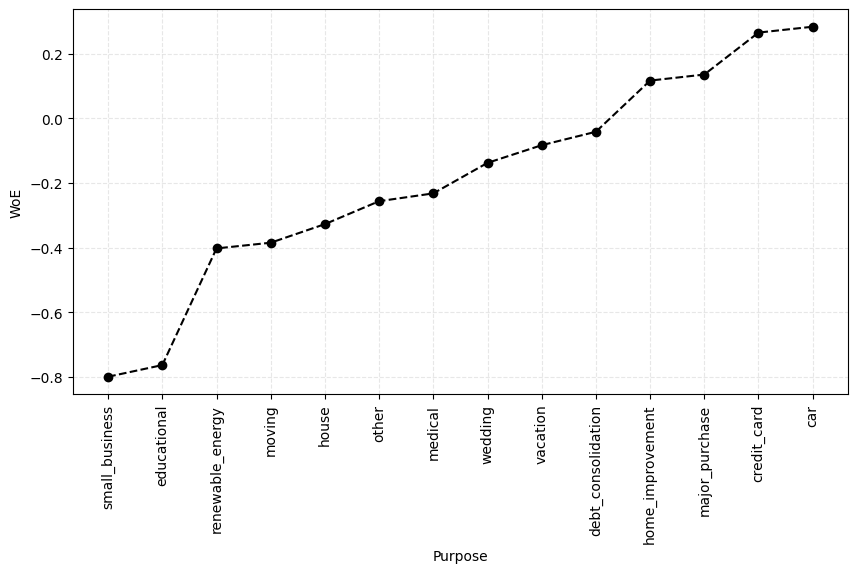

In [ ]:
plot_woe_by_category(woe_df, rotate=True)

Based on the WoE results, only a few categories should be combined for better representativeness:

- `educational` and `small_business`

- `house`, `moving`, and `renewable_energy`

- `vacation` and `wedding`

- `major_purchase` and `home_improvement`

All other categories can remain as they are.

In [ ]:
print("Original train categories:", df_train_mod['purpose'].unique())

# Define the mapping
category_mapping = {
    "car": ["car"],
    "credit_card": ["credit_card"],
    "major_purchase_home_improvement": ["major_purchase", "home_improvement"],
    "debt_consolidation": ["debt_consolidation"],
    "vacation_wedding": ["vacation", "wedding"],
    "medical": ['medical'],
    "other": ["other"],
    "renewable_energy_house_moving": ["renewable_energy", "house", "moving"],
    "educational_small_business": ["small_business", "educational"],
}

# Create flattened mapping for .replace()
flat_mapping = {}
for new_group, old_purposes in category_mapping.items():
    for purpose in old_purposes:
        flat_mapping[purpose] = new_group

print(f"Created {len(flat_mapping)} purpose-to-group mappings")

# Apply the mapping
df_train_mod['purpose'] = df_train_mod['purpose'].replace(flat_mapping)

print("New train categories:", df_train_mod['purpose'].unique())
print("Number of new categories:", df_train_mod['purpose'].nunique())
print("\nValue counts:")
print(df_train_mod['purpose'].value_counts())

Original train categories: ['car' 'credit_card' 'debt_consolidation' 'other' 'major_purchase'
 'home_improvement' 'small_business' 'house' 'wedding' 'moving' 'medical'
 'vacation' 'renewable_energy' 'educational']
Created 14 purpose-to-group mappings
New train categories: ['car' 'credit_card' 'debt_consolidation' 'other'
 'major_purchase_home_improvement' 'educational_small_business'
 'renewable_energy_house_moving' 'vacation_wedding' 'medical']
Number of new categories: 9

Value counts:
purpose
debt_consolidation                 219434
credit_card                         83206
major_purchase_home_improvement     29108
other                               19049
educational_small_business           5942
renewable_energy_house_moving        4476
car                                  4316
vacation_wedding                     3839
medical                              3658
Name: count, dtype: int64


In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name=variable,
    target_column_name=target_variable,
)
woe_df

,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
purpose,,,,,,,,
educational_small_business,4671.5,1271.5,5943.0,0.014060,0.031181,-0.796475,0.013636,0.036911
renewable_energy_house_moving,3806.5,670.5,4477.0,0.011456,0.016442,-0.361317,0.001802,0.036911
other,16442.5,2607.5,19050.0,0.049487,0.063943,-0.256281,0.003705,0.036911
medical,3168.5,490.5,3659.0,0.009536,0.012028,-0.232170,0.000579,0.036911
vacation_wedding,3377.5,462.5,3840.0,0.010165,0.011342,-0.109514,0.000129,0.036911
debt_consolidation,194540.5,24894.5,219435.0,0.585509,0.610481,-0.041765,0.001043,0.036911
major_purchase_home_improvement,26255.5,2853.5,29109.0,0.079021,0.069976,0.121571,0.001100,0.036911
credit_card,76044.5,7162.5,83207.0,0.228871,0.175644,0.264701,0.014089,0.036911
car,3951.5,365.5,4317.0,0.011893,0.008963,0.282826,0.000829,0.036911


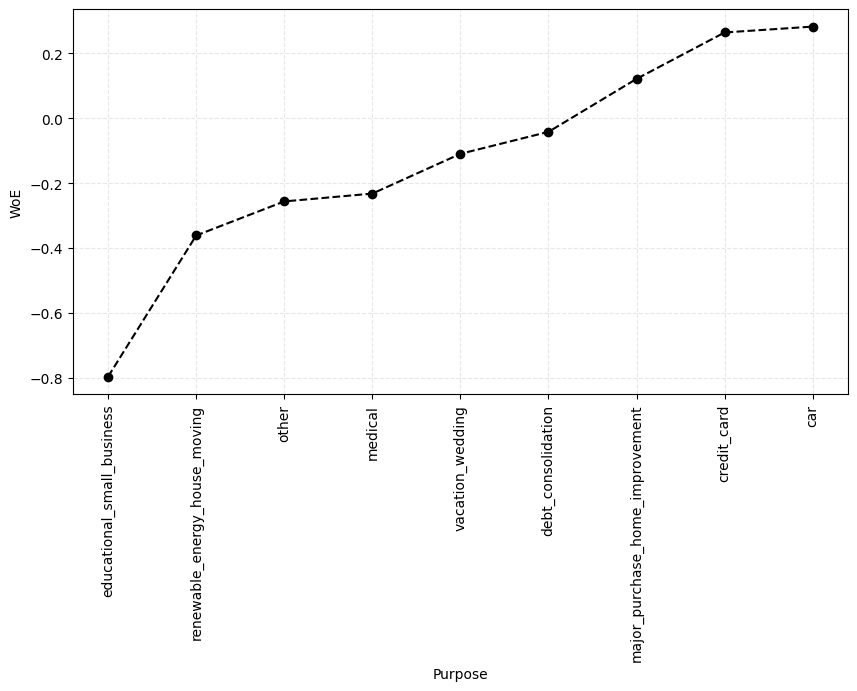

In [ ]:
plot_woe_by_category(woe_df, rotate = True)

In [ ]:
print("Original test categories:", df_test_mod['purpose'].unique())

df_test_mod['purpose'] = df_test_mod['purpose'].replace(flat_mapping)

print("New test categories:", df_test_mod['purpose'].unique())
print("Value counts:")
print(df_test_mod['purpose'].value_counts())

Original test categories: ['credit_card' 'home_improvement' 'debt_consolidation' 'other'
 'major_purchase' 'medical' 'car' 'wedding' 'small_business' 'educational'
 'vacation' 'house' 'moving' 'renewable_energy']
New test categories: ['credit_card' 'major_purchase_home_improvement' 'debt_consolidation'
 'other' 'medical' 'car' 'vacation_wedding' 'educational_small_business'
 'renewable_energy_house_moving']
Value counts:
purpose
debt_consolidation                 54761
credit_card                        20951
major_purchase_home_improvement     7257
other                               4641
educational_small_business          1493
renewable_energy_house_moving       1138
car                                 1081
vacation_wedding                     991
medical                              944
Name: count, dtype: int64


In [ ]:
variable = "initial_list_status"

In [ ]:
print(f"{df_train_mod[variable].isnull().sum():,} missing rows!\n\n")
print(df_train_mod[variable].value_counts())

0 missing rows!


initial_list_status
f    242532
w    130496
Name: count, dtype: int64


In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name=variable,
    target_column_name=target_variable,
)
woe_df

,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
initial_list_status,,,,,,,,
f,213361.5,29171.5,242533.0,0.642162,0.715426,-0.108038,0.007915,0.024699
w,118893.5,11603.5,130497.0,0.357838,0.284574,0.229088,0.016784,0.024699


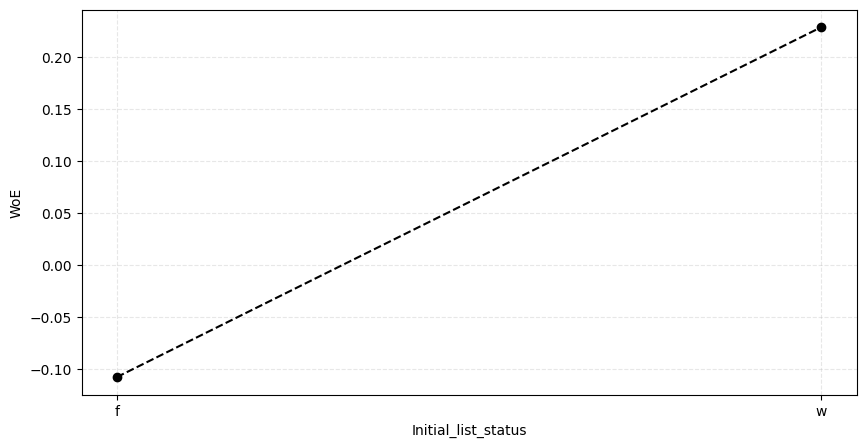

In [ ]:
plot_woe_by_category(woe_df)

Only two categories are present, no further adjustments are necessary.

## **Analyzing numerical variables**

Next, we focus on the numeric variables. The process is similar to what we did for categorical variables, but since these features are continuous, we will apply a two-stage strategy to convert them into appropriate categories:

**Fine Classing:** Roughly group values into intervals (e.g., constant-width bins).

**Coarse Classing:** Combine some of the fine bins into larger categories based on WoE behavior and representativeness.

The numeric variables we will analyze are:

- `term`

- `emp_length`

- `months_since_issue_d`

- `int_rate`

- `funded_amnt`

- `months_since_earliest_cr_line`

- `annual_inc`

- `delinq_2yrs`

- `inq_last_6_mths`

- `open_acc`

- `pub_rec`

- `total_acc`

- `dti`

- `total_rev_hi_lim`

In [ ]:
variable = "term"
print(f"{df_train_mod[variable].isnull().sum():,} missing rows!\n\n")
print(df_train_mod[variable].describe())

0 missing rows!


count    373028.000000
mean         42.588953
std          10.710783
min          36.000000
25%          36.000000
50%          36.000000
75%          60.000000
max          60.000000
Name: term, dtype: float64


In [ ]:
print(df_train_mod[variable].value_counts())

term
36    270617
60    102411
Name: count, dtype: int64


,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
term,,,,,,,,
60,87964.5,14447.5,102412.0,0.26475,0.354323,-0.291422,0.026103,0.03774
36,244290.5,26327.5,270618.0,0.73525,0.645677,0.129910,0.011636,0.03774


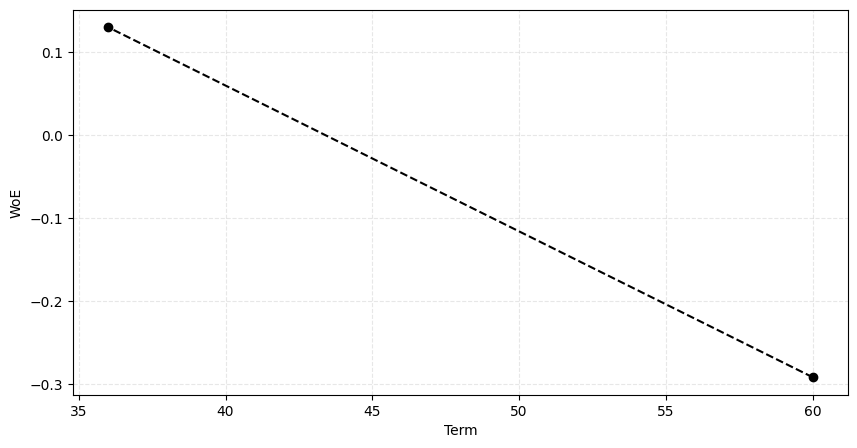

In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name=variable,
    target_column_name=target_variable,
)
display(woe_df)
plot_woe_by_category(woe_df)

Only two categories are present, no further adjustments are necessary.

In [ ]:
variable = "emp_length"
print(f"{df_train_mod[variable].isnull().sum():,} missing rows!\n\n")
print(df_train_mod[variable].value_counts())

16,889 missing rows!


emp_length
10.0    120251
2.0      33050
3.0      29323
0.0      28870
5.0      24627
1.0      23701
4.0      22462
6.0      20862
7.0      20847
8.0      17850
9.0      14296
Name: count, dtype: int64


From a business perspective, the highest-risk scenario corresponds to borrowers with less than 1 year of employment. Therefore, we will impute missing values with this category to adopt a conservative risk approach.

In [ ]:
df_train_mod[variable] = df_train_mod[variable].fillna(0)

Since there are only 10 categories, we can proceed with the standard WoE and IV analysis as usual.

,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
emp_length,,,,,,,,
0.0,40083.5,5676.5,45760.0,0.120639,0.139200,-0.143107,0.002656,0.006655
1.0,21040.5,2661.5,23702.0,0.063326,0.065266,-0.030178,0.000059,0.006655
2.0,29421.5,3629.5,33051.0,0.088550,0.089003,-0.005106,0.000002,0.006655
3.0,26075.5,3248.5,29324.0,0.078479,0.079660,-0.014934,0.000018,0.006655
4.0,20053.5,2409.5,22463.0,0.060355,0.059086,0.021248,0.000027,0.006655
5.0,21799.5,2828.5,24628.0,0.065610,0.069361,-0.055596,0.000209,0.006655
6.0,18444.5,2418.5,20863.0,0.055512,0.059307,-0.066118,0.000251,0.006655
7.0,18521.5,2326.5,20848.0,0.055744,0.057051,-0.023170,0.000030,0.006655
8.0,15845.5,2005.5,17851.0,0.047690,0.049179,-0.030745,0.000046,0.006655


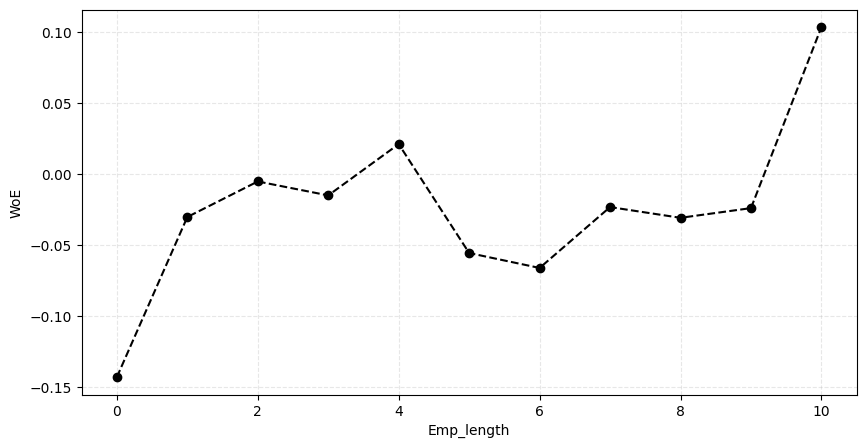

In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name=variable,
    target_column_name=target_variable,
    sort_by_woe=False
)
display(woe_df)
plot_woe_by_category(woe_df)

Based on the visualization above, we define the following final categories for employment length:

- <1y

- 1y

- 2-4y

- 5-6y

- 7-9y

- 10+y

In [ ]:
print("Original train categories:", df_train_mod['emp_length'].unique())

# Define the mapping
category_mapping = {
    "<1y": [0],
    "1y": [1],
    "2-4y": [2, 3, 4],
    "5-6y": [5, 6],
    "7-9y": [7, 8, 9],
    "10+y": [10]
}

# Create flattened mapping for .replace()
flat_mapping = {}
for new_group, old_emp in category_mapping.items():
    for emp in old_emp:
        flat_mapping[emp] = new_group

print(f"Created {len(flat_mapping)} emp-to-group mappings")

# Apply the mapping
df_train_mod['emp_length'] = df_train_mod['emp_length'].replace(flat_mapping)

print("New train categories:", df_train_mod['emp_length'].unique())
print("Number of new categories:", df_train_mod['emp_length'].nunique())
print("\nValue counts:")
print(df_train_mod['emp_length'].value_counts())

Original train categories: [ 0.  4.  3. 10.  5.  9.  8.  6.  2.  1.  7.]
Created 11 emp-to-group mappings
New train categories: ['<1y' '2-4y' '10+y' '5-6y' '7-9y' '1y']
Number of new categories: 6

Value counts:
emp_length
10+y    120251
2-4y     84835
7-9y     52993
<1y      45759
5-6y     45489
1y       23701
Name: count, dtype: int64


,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
emp_length,,,,,,,,
10+y,108273.5,11978.5,120252.0,0.325873,0.293756,0.103756,3.332291e-03,0.006601
1y,21040.5,2661.5,23702.0,0.063326,0.065270,-0.030231,5.875928e-05,0.006601
2-4y,75549.5,9286.5,84836.0,0.227383,0.227739,-0.001564,5.567996e-07,0.006601
5-6y,40243.5,5246.5,45490.0,0.121122,0.128663,-0.060403,4.555381e-04,0.006601
7-9y,47066.5,5927.5,52994.0,0.141657,0.145364,-0.025832,9.575515e-05,0.006601
<1y,40083.5,5676.5,45760.0,0.120640,0.139208,-0.143161,2.658254e-03,0.006601


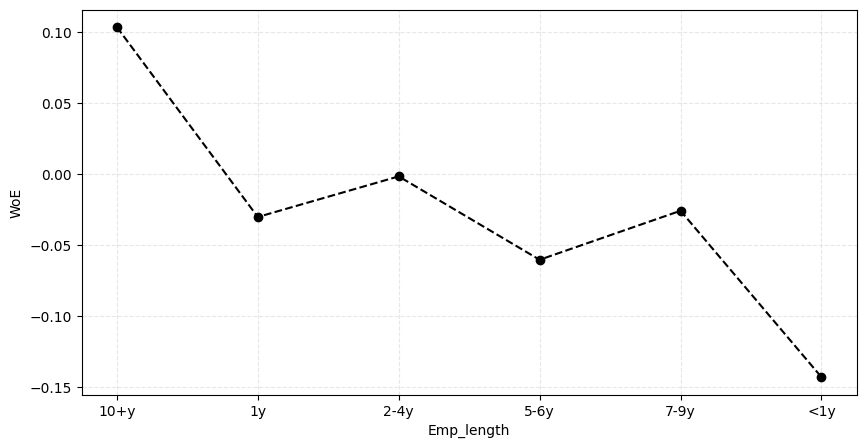

In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name=variable,
    target_column_name=target_variable,
    sort_by_woe=False
)
display(woe_df)
plot_woe_by_category(woe_df)

In [ ]:
df_test_mod[variable] = df_test_mod[variable].fillna(0)

print("Original test categories:", df_test_mod['emp_length'].unique())

df_test_mod['emp_length'] = df_test_mod['emp_length'].replace(flat_mapping)

print("New test categories:", df_test_mod['emp_length'].unique())
print("Value counts:")
print(df_test_mod['emp_length'].value_counts())

Original test categories: [ 1.  2. 10.  0.  5.  7.  6.  3.  8.  4.  9.]
New test categories: ['1y' '2-4y' '10+y' '<1y' '5-6y' '7-9y']
Value counts:
emp_length
10+y    29798
2-4y    21157
7-9y    13470
<1y     11514
5-6y    11397
1y       5921
Name: count, dtype: int64


In [ ]:
variable = "months_since_issue_date"
print(f"{df_train_mod[variable].isnull().sum():,} missing rows!\n\n")
print(df_train_mod[variable].describe())

0 missing rows!


count    373028.000000
mean         51.269104
std          14.342725
min          36.005256
25%          41.031537
50%          46.977661
75%          57.030223
max         126.018397
Name: months_since_issue_date, dtype: float64


In [ ]:
 # Let pandas automatically create equal bins
df_train_mod['months_since_issue_date_binned'] = pd.cut(
    df_train_mod['months_since_issue_date'],
    bins=30,
    include_lowest=True
)

print("Automatic equal bins:")
print(df_train_mod['months_since_issue_date_binned'].value_counts().sort_index())

Automatic equal bins:
months_since_issue_date_binned
(35.914, 39.006]      67650
(39.006, 42.006]      38596
(42.006, 45.007]      44181
(45.007, 48.007]      49996
(48.007, 51.007]      33467
(51.007, 54.008]      19564
(54.008, 57.008]      24591
(57.008, 60.009]      23061
(60.009, 63.009]      15002
(63.009, 66.01]       11107
(66.01, 69.01]         5345
(69.01, 72.011]        8283
(72.011, 75.011]       5130
(75.011, 78.011]       3056
(78.011, 81.012]       4020
(81.012, 84.012]       4359
(84.012, 87.013]       2876
(87.013, 90.013]       1903
(90.013, 93.014]       2452
(93.014, 96.014]       2267
(96.014, 99.014]       1423
(99.014, 102.015]      1016
(102.015, 105.015]      561
(105.015, 108.016]      916
(108.016, 111.016]      309
(111.016, 114.017]      288
(114.017, 117.017]      645
(117.017, 120.018]      633
(120.018, 123.018]      204
(123.018, 126.018]      127
Name: count, dtype: int64


/tmp/ipython-input-1485944256.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix = pd.pivot_table(


,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
months_since_issue_date_binned,,,,,,,,
"(35.914, 39.006]",63247.5,4403.5,67651.0,0.190350,0.107958,0.567123,0.046727,0.113398
"(39.006, 42.006]",35456.5,3140.5,38597.0,0.106710,0.076994,0.326392,0.009699,0.113398
"(42.006, 45.007]",40035.5,4146.5,44182.0,0.120491,0.101657,0.169970,0.003201,0.113398
"(45.007, 48.007]",44953.5,5043.5,49997.0,0.135292,0.123649,0.089996,0.001048,0.113398
"(48.007, 51.007]",29617.5,3850.5,33468.0,0.089137,0.094400,-0.057370,0.000302,0.113398
"(51.007, 54.008]",17109.5,2455.5,19565.0,0.051493,0.060200,-0.156229,0.001360,0.113398
"(54.008, 57.008]",21192.5,3399.5,24592.0,0.063781,0.083344,-0.267513,0.005233,0.113398
"(57.008, 60.009]",19853.5,3208.5,23062.0,0.059751,0.078661,-0.274956,0.005199,0.113398
"(60.009, 63.009]",12765.5,2237.5,15003.0,0.038419,0.054855,-0.356145,0.005854,0.113398


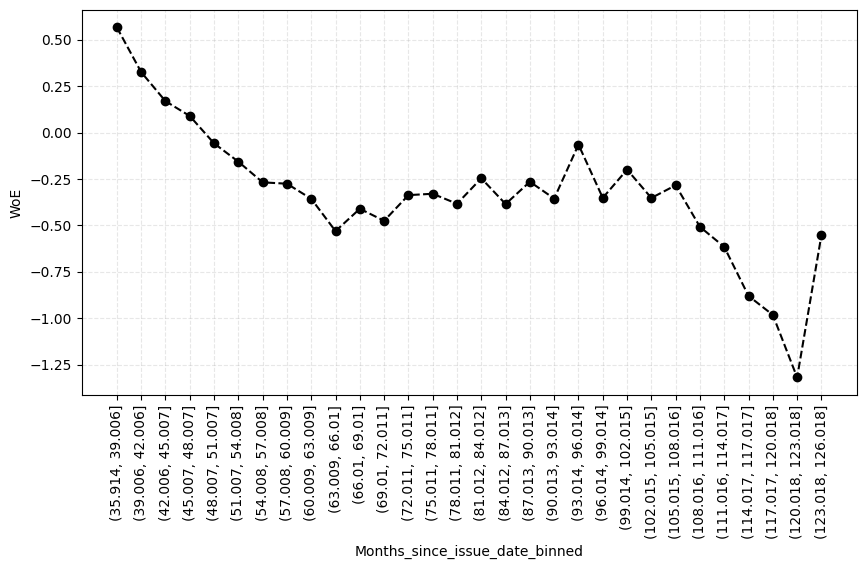

In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name='months_since_issue_date_binned',
    target_column_name=target_variable,
    sort_by_woe=False
)
display(woe_df)

# Convert the index (intervals) to strings for plotting
woe_df.index = woe_df.index.astype(str)

plot_woe_by_category(woe_df, rotate = True)

In [ ]:
# Use sensible boundaries that cover our data range
boundaries = [35, 39, 42, 45, 48, 51, 54, 63, 84, 127]

# Create bins
df_train_mod['months_since_issue_date_binned'] = pd.cut(
    df_train_mod['months_since_issue_date'],
    bins=boundaries,
    include_lowest=True
)

print("Bins created and their counts:")
bin_counts = df_train_mod['months_since_issue_date_binned'].value_counts().sort_index()
print(bin_counts)

Bins created and their counts:
months_since_issue_date_binned
(34.999, 39.0]    67650
(39.0, 42.0]      38596
(42.0, 45.0]      44181
(45.0, 48.0]      49996
(48.0, 51.0]      33467
(51.0, 54.0]      19564
(54.0, 63.0]      62654
(63.0, 84.0]      40251
(84.0, 127.0]     16669
Name: count, dtype: int64


/tmp/ipython-input-1485944256.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix = pd.pivot_table(


,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
months_since_issue_date_binned,,,,,,,,
"(34.999, 39.0]",63247.5,4403.5,67651.0,0.190356,0.107986,0.566898,0.046696,0.108748
"(39.0, 42.0]",35456.5,3140.5,38597.0,0.106714,0.077014,0.326166,0.009687,0.108748
"(42.0, 45.0]",40035.5,4146.5,44182.0,0.120495,0.101683,0.169744,0.003193,0.108748
"(45.0, 48.0]",44953.5,5043.5,49997.0,0.135297,0.123680,0.089770,0.001043,0.108748
"(48.0, 51.0]",29617.5,3850.5,33468.0,0.089140,0.094425,-0.057596,0.000304,0.108748
"(51.0, 54.0]",17109.5,2455.5,19565.0,0.051495,0.060216,-0.156455,0.001364,0.108748
"(54.0, 63.0]",53810.5,8844.5,62655.0,0.161954,0.216891,-0.292085,0.016046,0.108748
"(63.0, 84.0]",33862.5,6389.5,40252.0,0.101916,0.156688,-0.430106,0.023558,0.108748
"(84.0, 127.0]",14165.5,2504.5,16670.0,0.042634,0.061417,-0.365038,0.006857,0.108748


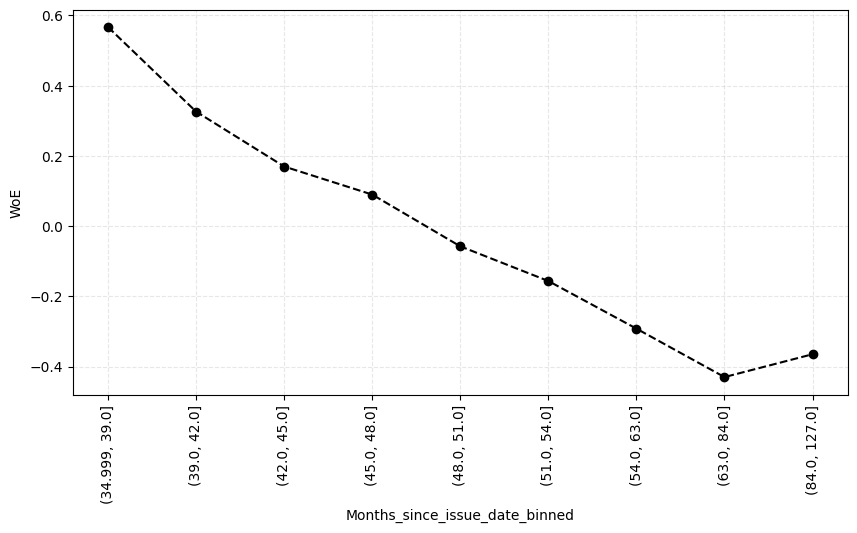

In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name='months_since_issue_date_binned',
    target_column_name=target_variable,
    sort_by_woe=False
)
display(woe_df)

# Convert the index (intervals) to strings for plotting
woe_df.index = woe_df.index.astype(str)

plot_woe_by_category(woe_df, rotate = True)

In [ ]:
df_test_mod['months_since_issue_date_binned'] = pd.cut(
    df_test_mod['months_since_issue_date'],
    bins=boundaries,
    include_lowest=True
)

print("Bins created and their counts:")
bin_counts = df_test_mod['months_since_issue_date_binned'].value_counts().sort_index()
print(bin_counts)

Bins created and their counts:
months_since_issue_date_binned
(34.999, 39.0]    17099
(39.0, 42.0]       9524
(42.0, 45.0]      11168
(45.0, 48.0]      12434
(48.0, 51.0]       8310
(51.0, 54.0]       5020
(54.0, 63.0]      15518
(63.0, 84.0]      10039
(84.0, 127.0]      4145
Name: count, dtype: int64


In [ ]:
variable = "int_rate"
print(f"{df_train_mod[variable].isnull().sum():,} missing rows!\n\n")
print(df_train_mod[variable].describe())

0 missing rows!


count    373028.000000
mean         13.830330
std           4.353664
min           5.420000
25%          10.990000
50%          13.660000
75%          16.490000
max          26.060000
Name: int_rate, dtype: float64


In [ ]:
# Let pandas automatically create equal bins
df_train_mod['int_rate_binned'] = pd.cut(
    df_train_mod['int_rate'],
    bins=30,
    include_lowest=True
)

print("Automatic equal bins:")
print(df_train_mod['int_rate_binned'].value_counts().sort_index())

Automatic equal bins:
int_rate_binned
(5.398, 6.108]       8967
(6.108, 6.796]       8202
(6.796, 7.484]       4826
(7.484, 8.172]      20838
(8.172, 8.86]        8044
(8.86, 9.548]       16163
(9.548, 10.236]     17664
(10.236, 10.924]     6617
(10.924, 11.612]    22778
(11.612, 12.3]      23449
(12.3, 12.988]      15745
(12.988, 13.676]    36530
(13.676, 14.364]    26782
(14.364, 15.052]    20374
(15.052, 15.74]     23045
(15.74, 16.428]     19431
(16.428, 17.116]    11949
(17.116, 17.804]    16982
(17.804, 18.492]    10313
(18.492, 19.18]     10713
(19.18, 19.868]      9314
(19.868, 20.556]     8110
(20.556, 21.244]     5216
(21.244, 21.932]     2491
(21.932, 22.62]      5323
(22.62, 23.308]      2395
(23.308, 23.996]     3688
(23.996, 24.684]     2979
(24.684, 25.372]     1637
(25.372, 26.06]      2463
Name: count, dtype: int64


/tmp/ipython-input-1485944256.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix = pd.pivot_table(


,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
int_rate_binned,,,,,,,,
"(5.398, 6.108]",8776.5,191.5,8968.0,0.026414,0.004695,1.727413,0.037518,0.339004
"(6.108, 6.796]",7965.5,237.5,8203.0,0.023973,0.005823,1.415175,0.025686,0.339004
"(6.796, 7.484]",4699.5,127.5,4827.0,0.014144,0.003126,1.509563,0.016632,0.339004
"(7.484, 8.172]",19920.5,918.5,20839.0,0.059953,0.022518,0.979230,0.036657,0.339004
"(8.172, 8.86]",7796.5,248.5,8045.0,0.023464,0.006092,1.348455,0.023425,0.339004
"(8.86, 9.548]",15372.5,791.5,16164.0,0.046265,0.019405,0.868873,0.023338,0.339004
"(9.548, 10.236]",16516.5,1148.5,17665.0,0.049708,0.028157,0.568371,0.012249,0.339004
"(10.236, 10.924]",6014.5,603.5,6618.0,0.018101,0.014796,0.201650,0.000667,0.339004
"(10.924, 11.612]",21146.5,1632.5,22779.0,0.063643,0.040023,0.463829,0.010955,0.339004


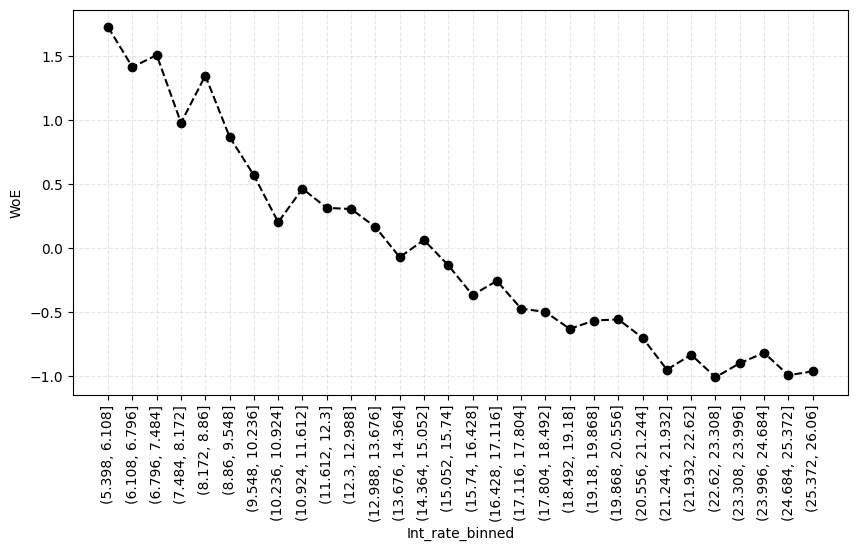

In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name='int_rate_binned',
    target_column_name=target_variable,
    sort_by_woe=False
)
display(woe_df)

# Convert the index (intervals) to strings for plotting
woe_df.index = woe_df.index.astype(str)

plot_woe_by_category(woe_df, rotate = True)

In [ ]:
# Use sensible boundaries that cover our data range
boundaries = [5.00,
6.00,
7.50,
8.90,
9.50,
10.20,
13.70,
15.70,
17.10,
20.50,
27.00]

# Create bins
df_train_mod['int_rate_binned'] = pd.cut(
    df_train_mod['int_rate'],
    bins=boundaries,
    include_lowest=True
)

print("Bins created and their counts:")
bin_counts = df_train_mod['int_rate_binned'].value_counts().sort_index()
print(bin_counts)

Bins created and their counts:
int_rate_binned
(4.999, 6.0]      1144
(6.0, 7.5]       22378
(7.5, 8.9]       36643
(8.9, 9.5]        6868
(9.5, 10.2]      17671
(10.2, 13.7]    106587
(13.7, 15.7]     68733
(15.7, 17.1]     31380
(17.1, 20.5]     55414
(20.5, 27.0]     26210
Name: count, dtype: int64


/tmp/ipython-input-1485944256.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix = pd.pivot_table(


,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
int_rate_binned,,,,,,,,
"(4.999, 6.0]",1095.5,49.5,1145.0,0.003297,0.001214,0.999246,0.002082,0.332198
"(6.0, 7.5]",21837.5,541.5,22379.0,0.065724,0.013279,1.599293,0.083876,0.332198
"(7.5, 8.9]",34962.5,1681.5,36644.0,0.105227,0.041234,0.936842,0.059951,0.332198
"(8.9, 9.5]",6629.5,239.5,6869.0,0.019953,0.005873,1.222984,0.017219,0.332198
"(9.5, 10.2]",16521.5,1150.5,17672.0,0.049725,0.028213,0.566718,0.012191,0.332198
"(10.2, 13.7]",97512.5,9075.5,106588.0,0.293483,0.222553,0.276655,0.019623,0.332198
"(13.7, 15.7]",60824.5,7909.5,68734.0,0.183064,0.193960,-0.057819,0.000630,0.332198
"(15.7, 17.1]",26815.5,4565.5,31381.0,0.080707,0.111957,-0.327296,0.010228,0.332198
"(17.1, 20.5]",45779.5,9635.5,55415.0,0.137783,0.236286,-0.539365,0.053129,0.332198


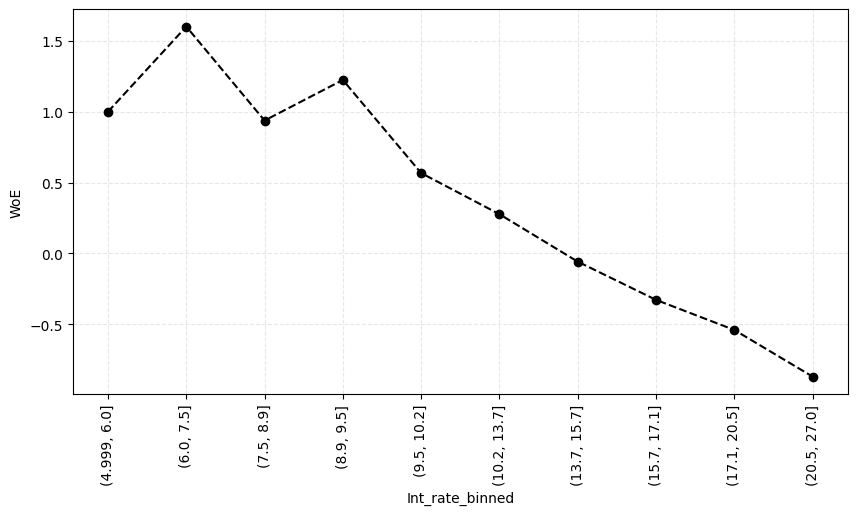

In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name='int_rate_binned',
    target_column_name=target_variable,
    sort_by_woe=False
)
display(woe_df)

# Convert the index (intervals) to strings for plotting
woe_df.index = woe_df.index.astype(str)

plot_woe_by_category(woe_df, rotate = True)

In [ ]:
df_test_mod['int_rate_binned'] = pd.cut(
    df_test_mod['int_rate'],
    bins=boundaries,
    include_lowest=True
)

print("Bins created and their counts:")
bin_counts = df_test_mod['int_rate_binned'].value_counts().sort_index()
print(bin_counts)

Bins created and their counts:
int_rate_binned
(4.999, 6.0]      286
(6.0, 7.5]       5693
(7.5, 8.9]       9232
(8.9, 9.5]       1724
(9.5, 10.2]      4520
(10.2, 13.7]    26400
(13.7, 15.7]    17074
(15.7, 17.1]     7759
(17.1, 20.5]    13891
(20.5, 27.0]     6678
Name: count, dtype: int64


In [ ]:
variable = "funded_amnt"
print(f"{df_train_mod[variable].isnull().sum():,} missing rows!\n\n")
print(df_train_mod[variable].describe())

0 missing rows!


count    373028.000000
mean      14289.637641
std        8275.754748
min         500.000000
25%        8000.000000
50%       12000.000000
75%       20000.000000
max       35000.000000
Name: funded_amnt, dtype: float64


In [ ]:
# Let pandas automatically create equal bins
df_train_mod['funded_amnt_binned'] = pd.cut(
    df_train_mod['funded_amnt'],
    bins=30,
    include_lowest=True
)

print("Automatic equal bins:")
print(df_train_mod['funded_amnt_binned'].value_counts().sort_index())

Automatic equal bins:
funded_amnt_binned
(465.499, 1650.0]      3643
(1650.0, 2800.0]       7887
(2800.0, 3950.0]      10861
(3950.0, 5100.0]      23883
(5100.0, 6250.0]      20063
(6250.0, 7400.0]      16928
(7400.0, 8550.0]      22825
(8550.0, 9700.0]      14538
(9700.0, 10850.0]     35855
(10850.0, 12000.0]    31090
(12000.0, 13150.0]     9566
(13150.0, 14300.0]    11509
(14300.0, 15450.0]    25621
(15450.0, 16600.0]    14582
(16600.0, 17750.0]     8540
(17750.0, 18900.0]    13563
(18900.0, 20050.0]    24652
(20050.0, 21200.0]     8268
(21200.0, 22350.0]     5167
(22350.0, 23500.0]     4316
(23500.0, 24650.0]    10807
(24650.0, 25800.0]    10776
(25800.0, 26950.0]     2525
(26950.0, 28100.0]     7822
(28100.0, 29250.0]     1772
(29250.0, 30400.0]     7679
(30400.0, 31550.0]     1189
(31550.0, 32700.0]     1829
(32700.0, 33850.0]     1296
(33850.0, 35000.0]    13976
Name: count, dtype: int64


/tmp/ipython-input-1485944256.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix = pd.pivot_table(


,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
funded_amnt_binned,,,,,,,,
"(465.499, 1650.0]",3265.5,378.5,3644.0,0.009828,0.009279,0.057420,3.148996e-05,0.006396
"(1650.0, 2800.0]",7041.5,846.5,7888.0,0.021192,0.020753,0.020934,9.190428e-06,0.006396
"(2800.0, 3950.0]",9676.5,1185.5,10862.0,0.029122,0.029064,0.002003,1.167454e-07,0.006396
"(3950.0, 5100.0]",21340.5,2543.5,23884.0,0.064227,0.062357,0.029533,5.519973e-05,0.006396
"(5100.0, 6250.0]",18090.5,1973.5,20064.0,0.054445,0.048383,0.118046,7.156179e-04,0.006396
"(6250.0, 7400.0]",15188.5,1740.5,16929.0,0.045711,0.042671,0.068834,2.092984e-04,0.006396
"(7400.0, 8550.0]",20409.5,2416.5,22826.0,0.061425,0.059244,0.036148,7.882810e-05,0.006396
"(8550.0, 9700.0]",12867.5,1671.5,14539.0,0.038726,0.040979,-0.056549,1.274070e-04,0.006396
"(9700.0, 10850.0]",31899.5,3956.5,35856.0,0.096005,0.096999,-0.010302,1.024161e-05,0.006396


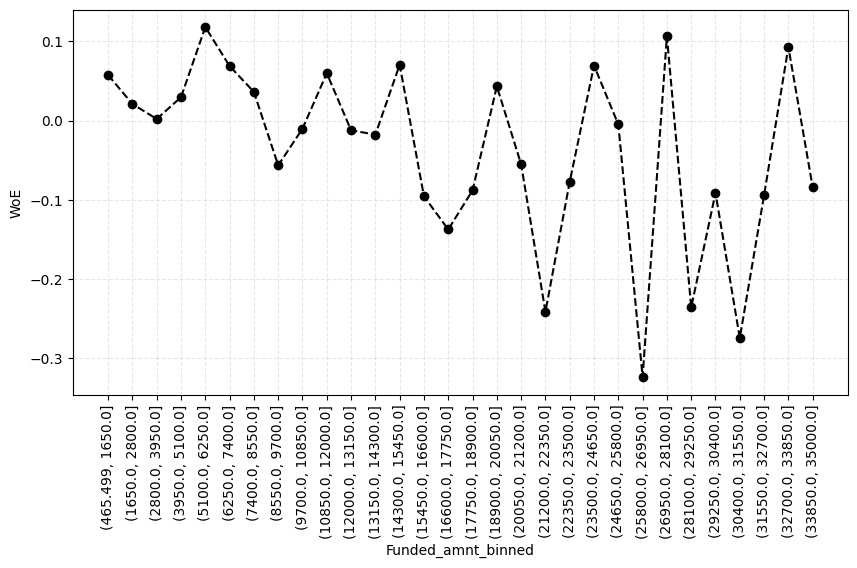

In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name='funded_amnt_binned',
    target_column_name=target_variable,
    sort_by_woe=False
)
display(woe_df)

# Convert the index (intervals) to strings for plotting
woe_df.index = woe_df.index.astype(str)

plot_woe_by_category(woe_df, rotate = True)

For `funded_amount`, there is clearly no meaningful association with the target variable. Therefore, we will exclude it from model development.

In [ ]:
variable = "months_since_earliest_cr_line"
print(f"{df_train_mod[variable].isnull().sum():,} missing rows!\n\n")
print(df_train_mod[variable].describe())

21 missing rows!


count    373007.000000
mean        242.428650
std          86.839689
min          72.996058
25%         184.001314
50%         225.952694
75%         285.019711
max         886.925099
Name: months_since_earliest_cr_line, dtype: float64


In [ ]:
df_train_mod[variable] = df_train_mod[variable].fillna(df_train_mod['months_since_issue_date'])

In [ ]:
# Let pandas automatically create equal bins
df_train_mod['months_since_earliest_cr_line_binned'] = pd.cut(
    df_train_mod['months_since_earliest_cr_line'],
    bins=30,
    include_lowest=True
)

print("Automatic equal bins:")
print(df_train_mod['months_since_earliest_cr_line_binned'].value_counts().sort_index())

Automatic equal bins:
months_since_earliest_cr_line_binned
(72.181, 100.127]      4384
(100.127, 127.258]    13789
(127.258, 154.389]    28800
(154.389, 181.52]     41599
(181.52, 208.651]     60331
(208.651, 235.782]    57300
(235.782, 262.913]    41811
(262.913, 290.044]    38430
(290.044, 317.175]    21771
(317.175, 344.306]    18735
(344.306, 371.437]    13993
(371.437, 398.568]    10188
(398.568, 425.699]     7485
(425.699, 452.83]      4122
(452.83, 479.961]      3737
(479.961, 507.092]     2404
(507.092, 534.223]     1468
(534.223, 561.353]     1056
(561.353, 588.484]      702
(588.484, 615.615]      438
(615.615, 642.746]      238
(642.746, 669.877]      124
(669.877, 697.008]       65
(697.008, 724.139]       29
(724.139, 751.27]        11
(751.27, 778.401]         8
(778.401, 805.532]        4
(805.532, 832.663]        2
(832.663, 859.794]        2
(859.794, 886.925]        2
Name: count, dtype: int64


/tmp/ipython-input-1485944256.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix = pd.pivot_table(


,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
months_since_earliest_cr_line_binned,,,,,,,,
"(72.181, 100.127]",3860.5,524.5,4385.0,0.011619,0.012859,-0.101426,1.257946e-04,0.014886
"(100.127, 127.258]",11943.5,1846.5,13790.0,0.035945,0.045270,-0.230637,2.150527e-03,0.014886
"(127.258, 154.389]",25099.5,3701.5,28801.0,0.075540,0.090748,-0.183423,2.789456e-03,0.014886
"(154.389, 181.52]",36778.5,4821.5,41600.0,0.110689,0.118206,-0.065704,4.938950e-04,0.014886
"(181.52, 208.651]",53491.5,6840.5,60332.0,0.160989,0.167705,-0.040871,2.744860e-04,0.014886
"(208.651, 235.782]",50768.5,6532.5,57301.0,0.152793,0.160153,-0.047046,3.462640e-04,0.014886
"(235.782, 262.913]",37274.5,4537.5,41812.0,0.112182,0.111243,0.008401,7.883891e-06,0.014886
"(262.913, 290.044]",34497.5,3933.5,38431.0,0.103824,0.096435,0.073825,5.454690e-04,0.014886
"(290.044, 317.175]",19703.5,2068.5,21772.0,0.059300,0.050712,0.156440,1.343452e-03,0.014886


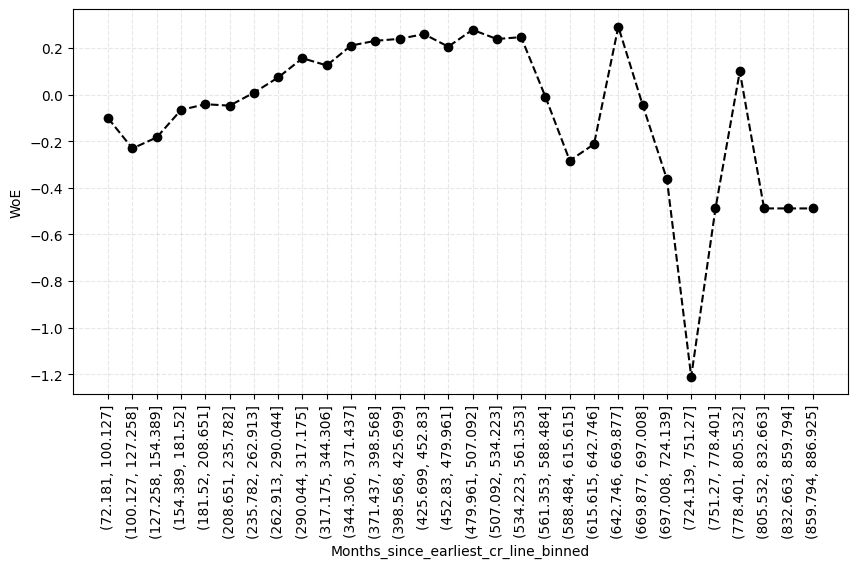

In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name='months_since_earliest_cr_line_binned',
    target_column_name=target_variable,
    sort_by_woe=False
)
display(woe_df)

# Convert the index (intervals) to strings for plotting
woe_df.index = woe_df.index.astype(str)

plot_woe_by_category(woe_df, rotate = True)

In [ ]:
# Use sensible boundaries that cover our data range
boundaries = [72,
    140,
    220,
    280,
    360,
    890]

# Create bins
df_train_mod['months_since_earliest_cr_line_binned'] = pd.cut(
    df_train_mod['months_since_earliest_cr_line'],
    bins=boundaries,
    include_lowest=True
)

print("Bins created and their counts:")
bin_counts = df_train_mod['months_since_earliest_cr_line_binned'].value_counts().sort_index()
print(bin_counts)

Bins created and their counts:
months_since_earliest_cr_line_binned
(71.999, 140.0]     30371
(140.0, 220.0]     143810
(220.0, 280.0]      99948
(280.0, 360.0]      61619
(360.0, 890.0]      37280
Name: count, dtype: int64


/tmp/ipython-input-1485944256.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix = pd.pivot_table(


,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
months_since_earliest_cr_line_binned,,,,,,,,
"(71.999, 140.0]",26359.5,4012.5,30372.0,0.079335,0.098402,-0.215387,0.004107,0.013456
"(140.0, 220.0]",127185.5,16625.5,143811.0,0.382793,0.407723,-0.063092,0.001573,0.013456
"(220.0, 280.0]",89077.5,10871.5,99949.0,0.268099,0.266612,0.005561,0.000008,0.013456
"(280.0, 360.0]",55668.5,5951.5,61620.0,0.167547,0.145954,0.137970,0.002979,0.013456
"(360.0, 890.0]",33965.5,3315.5,37281.0,0.102227,0.081309,0.228936,0.004789,0.013456


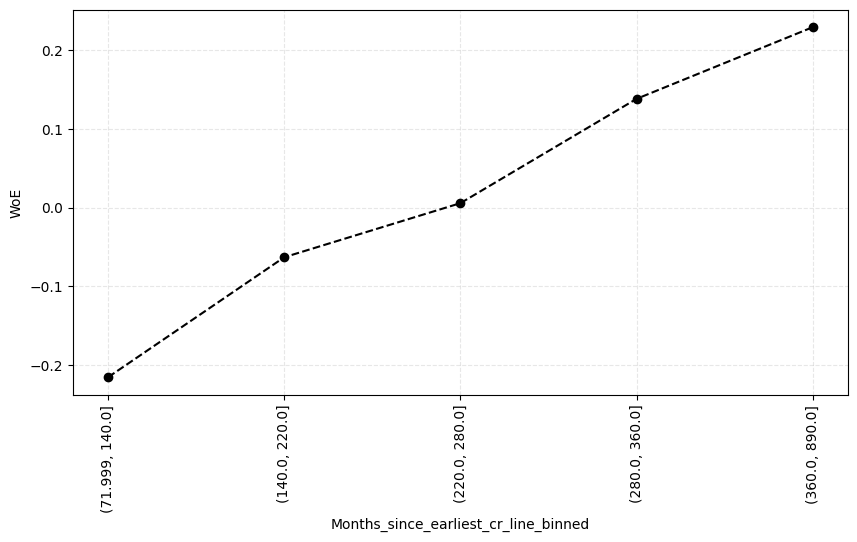

In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name='months_since_earliest_cr_line_binned',
    target_column_name=target_variable,
    sort_by_woe=False
)
display(woe_df)

# Convert the index (intervals) to strings for plotting
woe_df.index = woe_df.index.astype(str)

plot_woe_by_category(woe_df, rotate = True)

In [ ]:
df_test_mod[variable] = df_test_mod[variable].fillna(df_test_mod['months_since_issue_date'])

df_test_mod['months_since_earliest_cr_line_binned'] = pd.cut(
    df_test_mod['months_since_earliest_cr_line'],
    bins=boundaries,
    include_lowest=True
)

print("Bins created and their counts:")
bin_counts = df_test_mod['months_since_earliest_cr_line_binned'].value_counts().sort_index()
print(bin_counts)

Bins created and their counts:
months_since_earliest_cr_line_binned
(71.999, 140.0]     7657
(140.0, 220.0]     35989
(220.0, 280.0]     24744
(280.0, 360.0]     15395
(360.0, 890.0]      9472
Name: count, dtype: int64


In [ ]:
variable = "annual_inc"

print(f"{df_train_mod[variable].isnull().sum():,} missing rows!\n\n")
df_train_mod[variable] = df_train_mod[variable].fillna(df_train_mod[variable].min())
print(df_train_mod[variable].describe(percentiles=[0.25, 0.75, 0.90, 0.95]).round())

4 missing rows!


count     373028.0
mean       73312.0
std        55708.0
min         2000.0
25%        45000.0
50%        63000.0
75%        89000.0
90%       120000.0
95%       150000.0
max      7500000.0
Name: annual_inc, dtype: float64


The `annual_income` variable is highly skewed. To mitigate the impact of extreme values, we will winsorize it between the 90th and 95th percentile ($140k). From a business perspective, this approach is reasonable, as very high-income borrowers should be treated consistently with the rest of the population.

In [ ]:
df_train_mod[variable] = np.where(df_train_mod[variable] > 140_000, 140_000, df_train_mod[variable])

<Axes: xlabel='annual_inc', ylabel='Count'>

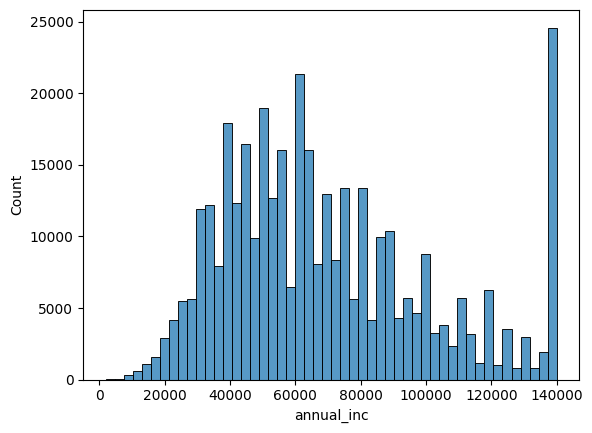

In [ ]:
sns.histplot(df_train_mod.annual_inc, bins = 50)

In [ ]:
# Let pandas automatically create equal bins
df_train_mod['annual_inc_binned'] = pd.cut(
    df_train_mod['annual_inc'],
    bins=30,
    include_lowest=True
)

print("Automatic equal bins:")
print(df_train_mod['annual_inc_binned'].value_counts().sort_index())

Automatic equal bins:
annual_inc_binned
(1861.999, 6600.0]         40
(6600.0, 11200.0]         443
(11200.0, 15800.0]       1606
(15800.0, 20400.0]       3743
(20400.0, 25000.0]       8211
(25000.0, 29600.0]       7865
(29600.0, 34200.0]      17081
(34200.0, 38800.0]      19331
(38800.0, 43400.0]      25984
(43400.0, 48000.0]      25355
(48000.0, 52600.0]      26011
(52600.0, 57200.0]      22776
(57200.0, 61800.0]      23321
(61800.0, 66400.0]      22496
(66400.0, 71000.0]      19911
(71000.0, 75600.0]      18896
(75600.0, 80200.0]      17221
(80200.0, 84800.0]       7761
(84800.0, 89400.0]      12787
(89400.0, 94000.0]      13017
(94000.0, 98600.0]       9164
(98600.0, 103200.0]     11041
(103200.0, 107800.0]     5405
(107800.0, 112400.0]     7360
(112400.0, 117000.0]     4216
(117000.0, 121600.0]     6640
(121600.0, 126200.0]     4273
(126200.0, 130800.0]     3595
(130800.0, 135400.0]     2410
(135400.0, 140000.0]    25068
Name: count, dtype: int64


/tmp/ipython-input-1485944256.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix = pd.pivot_table(


,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
annual_inc_binned,,,,,,,,
"(1861.999, 6600.0]",31.5,9.5,41.0,0.000095,0.000233,-0.898837,1.241322e-04,0.055781
"(6600.0, 11200.0]",375.5,68.5,444.0,0.001130,0.001679,-0.396108,2.175685e-04,0.055781
"(11200.0, 15800.0]",1329.5,277.5,1607.0,0.004001,0.006803,-0.530795,1.487303e-03,0.055781
"(15800.0, 20400.0]",3202.5,541.5,3744.0,0.009638,0.013276,-0.320188,1.164642e-03,0.055781
"(20400.0, 25000.0]",6979.5,1232.5,8212.0,0.021006,0.030216,-0.363600,3.349085e-03,0.055781
"(25000.0, 29600.0]",6717.5,1148.5,7866.0,0.020217,0.028157,-0.331273,2.630325e-03,0.055781
"(29600.0, 34200.0]",14698.5,2383.5,17082.0,0.044237,0.058435,-0.278357,3.952147e-03,0.055781
"(34200.0, 38800.0]",16672.5,2659.5,19332.0,0.050178,0.065201,-0.261910,3.934852e-03,0.055781
"(38800.0, 43400.0]",22533.5,3451.5,25985.0,0.067817,0.084618,-0.221338,3.718784e-03,0.055781


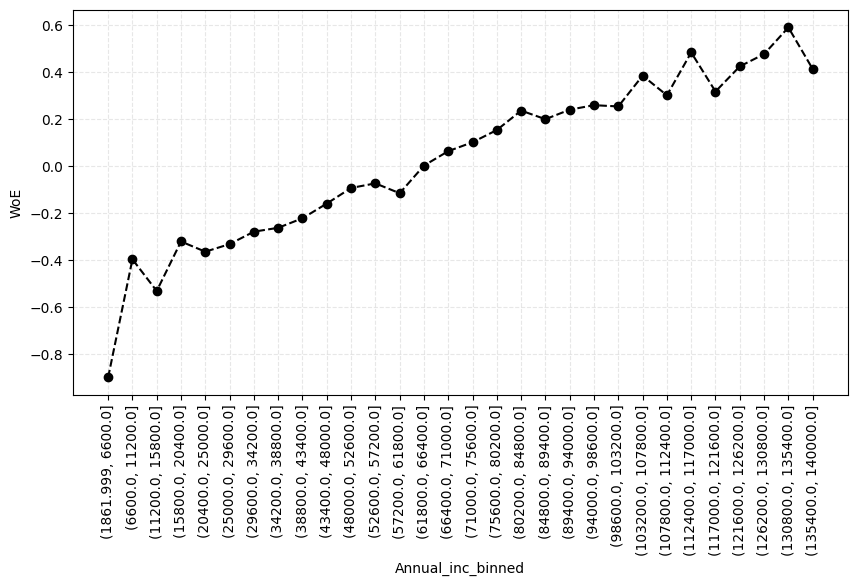

In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name='annual_inc_binned',
    target_column_name=target_variable,
    sort_by_woe=False
)
display(woe_df)

# Convert the index (intervals) to strings for plotting
woe_df.index = woe_df.index.astype(str)

plot_woe_by_category(woe_df, rotate = True)

In [ ]:
# Use sensible boundaries that cover our data range
boundaries = [0,
    20_000,
    30_000,
    40_000,
    50_000,
    60_000,
    70_000,
    80_000,
    90_000,
    100_000,
    120_000,
    141_000]

# Create bins
df_train_mod['annual_inc_binned'] = pd.cut(
    df_train_mod['annual_inc'],
    bins=boundaries,
    include_lowest=True
)

print("Bins created and their counts:")
bin_counts = df_train_mod['annual_inc_binned'].value_counts().sort_index()
print(bin_counts)

Bins created and their counts:
annual_inc_binned
(-0.001, 20000.0]        5662
(20000.0, 30000.0]      22480
(30000.0, 40000.0]      43161
(40000.0, 50000.0]      54833
(50000.0, 60000.0]      53034
(60000.0, 70000.0]      43406
(70000.0, 80000.0]      37594
(80000.0, 90000.0]      28098
(90000.0, 100000.0]     22585
(100000.0, 120000.0]    26478
(120000.0, 141000.0]    35697
Name: count, dtype: int64


/tmp/ipython-input-1485944256.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix = pd.pivot_table(


,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
annual_inc_binned,,,,,,,,
"(-0.001, 20000.0]",4788.5,874.5,5663.0,0.014412,0.021445,-0.397417,0.002795,0.055033
"(20000.0, 30000.0]",19220.5,3260.5,22481.0,0.057848,0.079954,-0.323640,0.007155,0.055033
"(30000.0, 40000.0]",37211.5,5950.5,43162.0,0.111995,0.145919,-0.264594,0.008976,0.055033
"(40000.0, 50000.0]",47941.5,6892.5,54834.0,0.144289,0.169019,-0.158189,0.003912,0.055033
"(50000.0, 60000.0]",46773.5,6261.5,53035.0,0.140774,0.153545,-0.086840,0.001109,0.055033
"(60000.0, 70000.0]",38774.5,4632.5,43407.0,0.116699,0.113599,0.026929,0.000083,0.055033
"(70000.0, 80000.0]",33922.5,3672.5,37595.0,0.102096,0.090058,0.125469,0.001511,0.055033
"(80000.0, 90000.0]",25574.5,2524.5,28099.0,0.076971,0.061906,0.217816,0.003281,0.055033
"(90000.0, 100000.0]",20617.5,1968.5,22586.0,0.062052,0.048272,0.251132,0.003461,0.055033


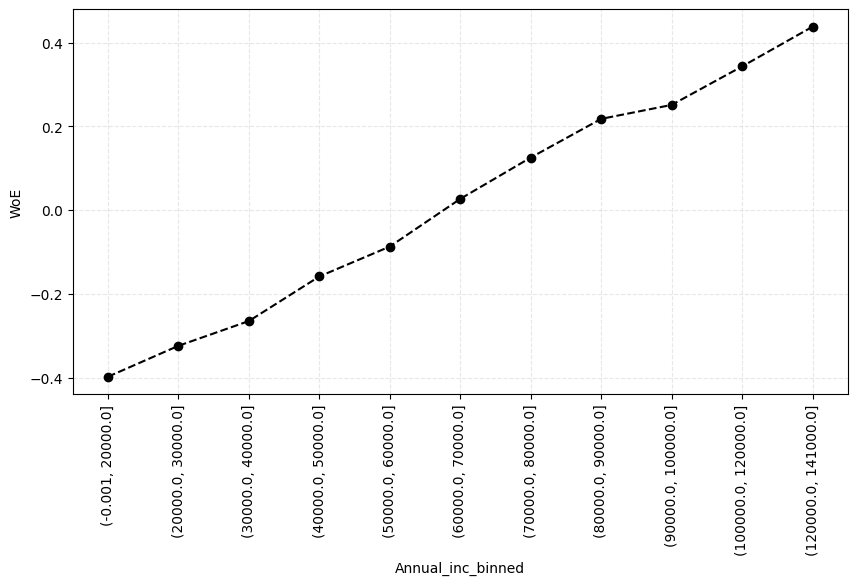

In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name='annual_inc_binned',
    target_column_name=target_variable,
    sort_by_woe=False
)
display(woe_df)

# Convert the index (intervals) to strings for plotting
woe_df.index = woe_df.index.astype(str)

plot_woe_by_category(woe_df, rotate = True)

In [ ]:
df_test_mod[variable] = df_test_mod[variable].fillna(df_test_mod[variable].min())
df_test_mod[variable] = np.where(df_test_mod[variable] > 140_000, 140_000, df_test_mod[variable])

df_test_mod['annual_inc_binned'] = pd.cut(
    df_test_mod['annual_inc'],
    bins=boundaries,
    include_lowest=True
)

print("Bins created and their counts:")
bin_counts = df_test_mod['annual_inc_binned'].value_counts().sort_index()
print(bin_counts)

Bins created and their counts:
annual_inc_binned
(-0.001, 20000.0]        1430
(20000.0, 30000.0]       5540
(30000.0, 40000.0]      10803
(40000.0, 50000.0]      13810
(50000.0, 60000.0]      13480
(60000.0, 70000.0]      10759
(70000.0, 80000.0]       9285
(80000.0, 90000.0]       6941
(90000.0, 100000.0]      5727
(100000.0, 120000.0]     6534
(120000.0, 141000.0]     8948
Name: count, dtype: int64


In [ ]:
variable = "delinq_2yrs"
print(f"{df_train_mod[variable].isnull().sum():,} missing rows!\n\n")
df_train_mod[variable] = df_train_mod[variable].fillna(df_train_mod[variable].max())
print(df_train_mod[variable].describe(percentiles=[0.25, 0.75, 0.90, 0.95, 0.999]))

21 missing rows!


count    373028.000000
mean          0.286866
std           0.827162
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
90%           1.000000
95%           2.000000
99.9%         8.000000
max          29.000000
Name: delinq_2yrs, dtype: float64


The `delinq_2yrs` variable is highly skewed. To limit the influence of extreme values, we will winsorize it at the 99.9th percentile (value = 8).

In [ ]:
df_train_mod[variable] = np.where(df_train_mod[variable] > 8, 8, df_train_mod[variable])

<Axes: xlabel='delinq_2yrs', ylabel='Count'>

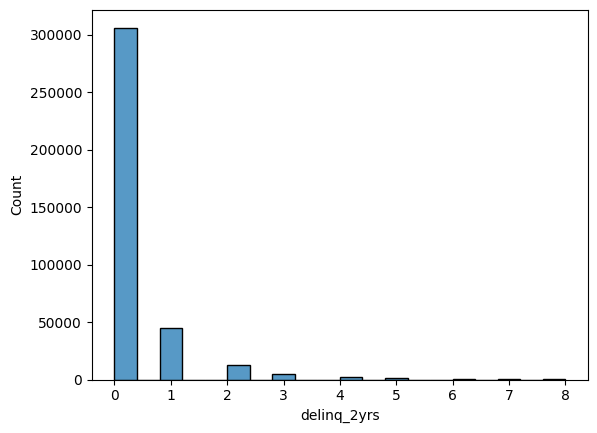

In [ ]:
sns.histplot(df_train_mod[variable])

In [ ]:
# Let pandas automatically create equal bins
df_train_mod['delinq_2yrs_binned'] = pd.cut(
    df_train_mod['delinq_2yrs'],
    bins=4,
    include_lowest=True
)

print("Automatic equal bins:")
print(df_train_mod['delinq_2yrs_binned'].value_counts().sort_index())

Automatic equal bins:
delinq_2yrs_binned
(-0.009000000000000001, 2.0]    364397
(2.0, 4.0]                        6452
(4.0, 6.0]                        1486
(6.0, 8.0]                         693
Name: count, dtype: int64


/tmp/ipython-input-1485944256.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix = pd.pivot_table(


,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
delinq_2yrs_binned,,,,,,,,
"(-0.009000000000000001, 2.0]",324607.5,39790.5,364398.0,0.976980,0.975831,0.001176,0.000001,0.000065
"(2.0, 4.0]",5718.5,734.5,6453.0,0.017211,0.018013,-0.045540,0.000037,0.000065
"(4.0, 6.0]",1319.5,167.5,1487.0,0.003971,0.004108,-0.033787,0.000005,0.000065
"(6.0, 8.0]",610.5,83.5,694.0,0.001837,0.002048,-0.108380,0.000023,0.000065


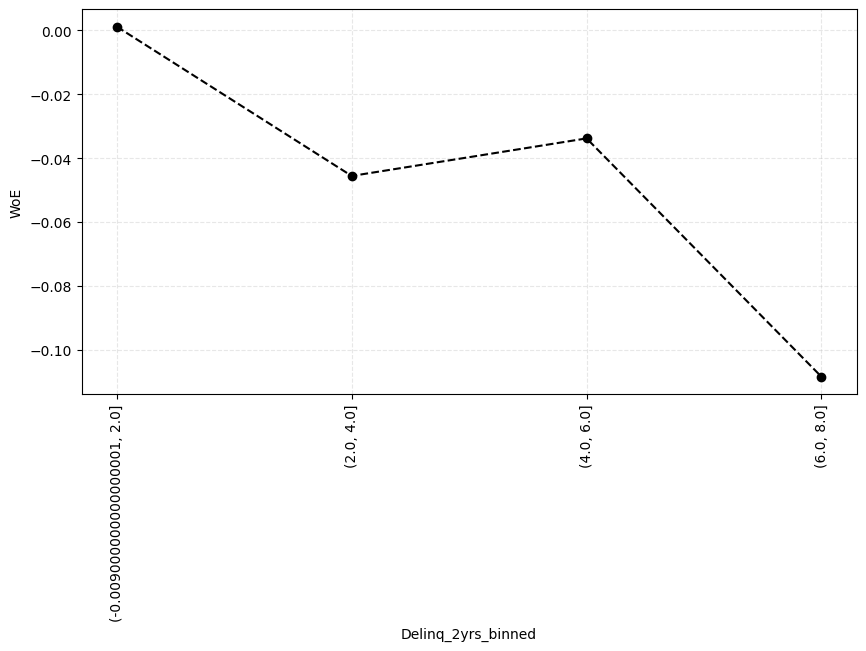

In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name='delinq_2yrs_binned',
    target_column_name=target_variable,
    sort_by_woe=False
)
display(woe_df)

# Convert the index (intervals) to strings for plotting
woe_df.index = woe_df.index.astype(str)

plot_woe_by_category(woe_df, rotate = True)

In [ ]:
# Use sensible boundaries that cover our data range
boundaries = [0,
    1.0,
    4.0,
    8.0]

labels = ['0-1', '2-4', '5-8']

# Create bins
df_train_mod['delinq_2yrs_binned'] = pd.cut(
    df_train_mod['delinq_2yrs'],
    bins=boundaries,
    labels=labels,
    include_lowest=True
)

print("Bins created and their counts:")
bin_counts = df_train_mod['delinq_2yrs_binned'].value_counts().sort_index()
print(bin_counts)

Bins created and their counts:
delinq_2yrs_binned
0-1    351321
2-4     19528
5-8      2179
Name: count, dtype: int64


/tmp/ipython-input-1485944256.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix = pd.pivot_table(


,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
delinq_2yrs_binned,,,,,,,,
0-1,313007.5,38314.5,351322.0,0.942069,0.939645,0.002576,0.000006,0.000107
2-4,17318.5,2210.5,19529.0,0.052124,0.054211,-0.039266,0.000082,0.000107
5-8,1929.5,250.5,2180.0,0.005807,0.006143,-0.056266,0.000019,0.000107


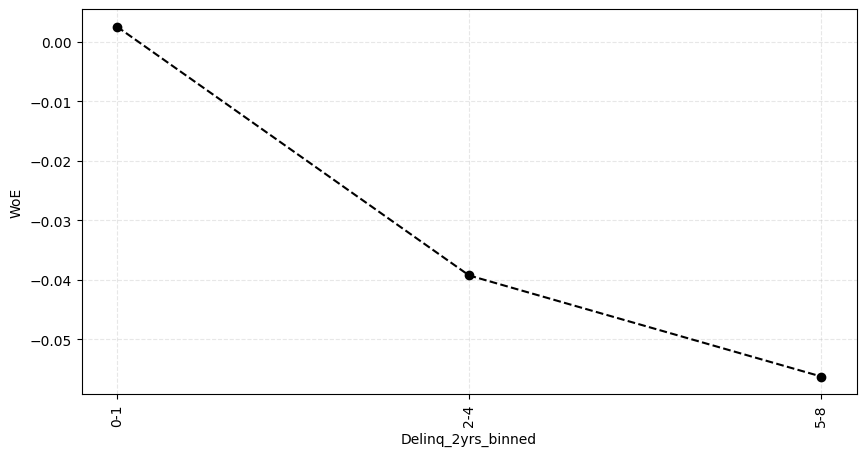

In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name='delinq_2yrs_binned',
    target_column_name=target_variable,
    sort_by_woe=False
)
display(woe_df)

# Convert the index (intervals) to strings for plotting
woe_df.index = woe_df.index.astype(str)

plot_woe_by_category(woe_df, rotate = True)

In [ ]:
df_train_mod = df_train_mod.drop(columns= 'delinq_2yrs')

In [ ]:
df_test_mod[variable] = df_test_mod[variable].fillna(df_test_mod[variable].max())

df_test_mod[variable] = np.where(df_test_mod[variable] > 8, 8, df_test_mod[variable])

df_test_mod['delinq_2yrs_binned'] = pd.cut(
    df_test_mod['delinq_2yrs'],
    bins=boundaries,
    labels=labels,
    include_lowest=True
)

print("Bins created and their counts:")
bin_counts = df_test_mod['delinq_2yrs_binned'].value_counts().sort_index()
print(bin_counts)

Bins created and their counts:
delinq_2yrs_binned
0-1    87857
2-4     4844
5-8      556
Name: count, dtype: int64


In [ ]:
variable = "inq_last_6mths"

print(f"{df_train_mod[variable].isnull().sum():,} missing rows!\n\n")
df_train_mod[variable] = df_train_mod[variable].fillna(df_train_mod[variable].max())

print(df_train_mod[variable].describe(percentiles=[0.25, 0.75, 0.90, 0.95, 0.999]))

21 missing rows!


count    373028.000000
mean          0.807248
std           1.118356
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
90%           2.000000
95%           3.000000
99.9%         7.000000
max          33.000000
Name: inq_last_6mths, dtype: float64


The `inq_last_6mths` variable is highly skewed. To reduce the impact of outliers, we will winsorize it at the 99.9th percentile (value = 7).

In [ ]:
df_train_mod[variable] = np.where(df_train_mod[variable] > 7, 7, df_train_mod[variable])

<Axes: xlabel='inq_last_6mths', ylabel='Count'>

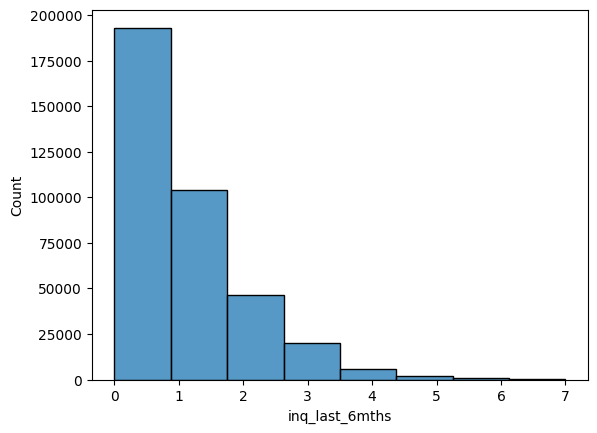

In [ ]:
sns.histplot(df_train_mod[variable], bins = 8)

In [ ]:
# Let pandas automatically create equal bins
df_train_mod['inq_last_6mths_binned'] = pd.cut(
    df_train_mod['inq_last_6mths'],
    bins=7,
    include_lowest=True
)

print("Automatic equal bins:")
print(df_train_mod['inq_last_6mths_binned'].value_counts().sort_index())

Automatic equal bins:
inq_last_6mths_binned
(-0.008, 1.0]    297266
(1.0, 2.0]        46286
(2.0, 3.0]        20125
(3.0, 4.0]         5772
(4.0, 5.0]         2229
(5.0, 6.0]          961
(6.0, 7.0]          389
Name: count, dtype: int64


/tmp/ipython-input-1485944256.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix = pd.pivot_table(


,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
inq_last_6mths_binned,,,,,,,,
"(-0.008, 1.0]",267608.5,29658.5,297267.0,0.805425,0.727325,0.101997,0.007966,0.039106
"(1.0, 2.0]",39976.5,6310.5,46287.0,0.120318,0.154754,-0.251703,0.008668,0.039106
"(2.0, 3.0]",16936.5,3189.5,20126.0,0.050974,0.078217,-0.428173,0.011665,0.039106
"(3.0, 4.0]",4872.5,900.5,5773.0,0.014665,0.022083,-0.409368,0.003037,0.039106
"(4.0, 5.0]",1851.5,378.5,2230.0,0.005572,0.009282,-0.510244,0.001893,0.039106
"(5.0, 6.0]",756.5,205.5,962.0,0.002277,0.005040,-0.794523,0.002195,0.039106
"(6.0, 7.0]",255.5,134.5,390.0,0.000769,0.003298,-1.456122,0.003683,0.039106


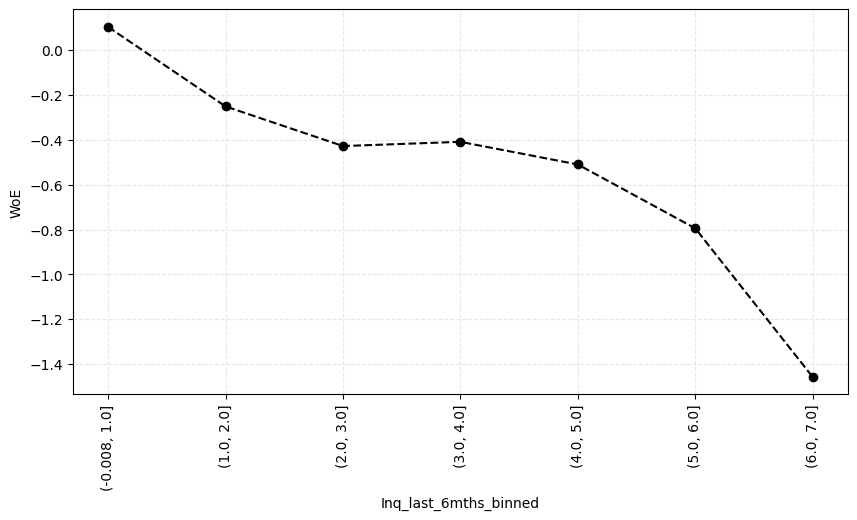

In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name='inq_last_6mths_binned',
    target_column_name=target_variable,
    sort_by_woe=False
)
display(woe_df)

# Convert the index (intervals) to strings for plotting
woe_df.index = woe_df.index.astype(str)

plot_woe_by_category(woe_df, rotate = True)

In [ ]:
# Use sensible boundaries that cover our data range
boundaries = [-0.01,
              0,
              1.0,
              2.0,
              4.0,
              5.0,
              7.0]

labels = ['0', '1', '2', '3-4', '5', '6 +']

# Create bins
df_train_mod['inq_last_6mths_binned'] = pd.cut(
    df_train_mod['inq_last_6mths'],
    bins=boundaries,
    labels=labels,
    include_lowest=True
)

print("Bins created and their counts:")
bin_counts = df_train_mod['inq_last_6mths_binned'].value_counts().sort_index()
print(bin_counts)

Bins created and their counts:
inq_last_6mths_binned
0      193063
1      104203
2       46286
3-4     25897
5        2229
6 +      1350
Name: count, dtype: int64


/tmp/ipython-input-1485944256.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix = pd.pivot_table(


,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
inq_last_6mths_binned,,,,,,,,
0,175476.5,17587.5,193064.0,0.528135,0.431309,0.202526,0.019610,0.0514
1,92132.5,12071.5,104204.0,0.277293,0.296037,-0.065410,0.001226,0.0514
2,39976.5,6310.5,46287.0,0.120318,0.154756,-0.251714,0.008669,0.0514
3-4,21808.5,4089.5,25898.0,0.065637,0.100289,-0.423913,0.014689,0.0514
5,1851.5,378.5,2230.0,0.005572,0.009282,-0.510255,0.001893,0.0514
6 +,1011.5,339.5,1351.0,0.003044,0.008326,-1.006075,0.005314,0.0514


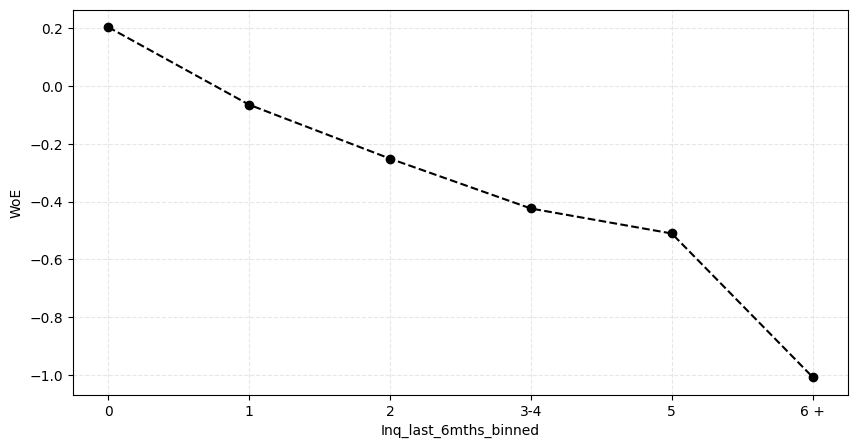

In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name='inq_last_6mths_binned',
    target_column_name=target_variable,
    sort_by_woe=False
)
display(woe_df)

# Convert the index (intervals) to strings for plotting
woe_df.index = woe_df.index.astype(str)

plot_woe_by_category(woe_df, rotate = False)

In [ ]:
df_test_mod[variable] = df_test_mod[variable].fillna(df_test_mod[variable].max())

df_test_mod[variable] = np.where(df_test_mod[variable] > 7, 7, df_test_mod[variable])

df_test_mod['inq_last_6mths_binned'] = pd.cut(
    df_test_mod['inq_last_6mths'],
    bins=boundaries,
    labels=labels,
    include_lowest=True
)

print("Bins created and their counts:")
bin_counts = df_test_mod['inq_last_6mths_binned'].value_counts().sort_index()
print(bin_counts)

Bins created and their counts:
inq_last_6mths_binned
0      48435
1      25945
2      11539
3-4     6470
5        539
6 +      329
Name: count, dtype: int64


In [ ]:
variable = "open_acc"
print(f"{df_train_mod[variable].isnull().sum():,} missing rows!\n\n")
df_train_mod[variable] = df_train_mod[variable].fillna(df_train_mod[variable].max())
print(df_train_mod[variable].describe(percentiles=[0.25, 0.75, 0.90, 0.95, 0.999]))

21 missing rows!


count    373028.000000
mean         11.188975
std           5.021078
min           0.000000
25%           8.000000
50%          10.000000
75%          14.000000
90%          18.000000
95%          20.000000
99.9%        37.000000
max          84.000000
Name: open_acc, dtype: float64


The `open_acc` variable is highly skewed. To limit the effect of extreme values, we will winsorize it at the 95th percentile (value = 20).


In [ ]:
df_train_mod[variable] = np.where(df_train_mod[variable] > 20, 20, df_train_mod[variable])

<Axes: xlabel='open_acc', ylabel='Count'>

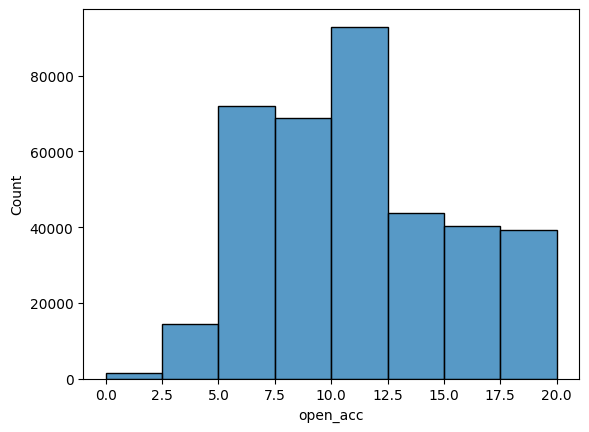

In [ ]:
sns.histplot(df_train_mod[variable], bins = 8)

In [ ]:
# Let pandas automatically create equal bins
df_train_mod['open_acc_binned'] = pd.cut(
    df_train_mod['open_acc'],
    bins=20,
    include_lowest=True
)

print("Automatic equal bins:")
print(df_train_mod['open_acc_binned'].value_counts().sort_index())

Automatic equal bins:
open_acc_binned
(-0.021, 1.0]      110
(1.0, 2.0]        1443
(2.0, 3.0]        4402
(3.0, 4.0]       10070
(4.0, 5.0]       17298
(5.0, 6.0]       24734
(6.0, 7.0]       29993
(7.0, 8.0]       33568
(8.0, 9.0]       35234
(9.0, 10.0]      34039
(10.0, 11.0]     31251
(11.0, 12.0]     27650
(12.0, 13.0]     23859
(13.0, 14.0]     19818
(14.0, 15.0]     16141
(15.0, 16.0]     13470
(16.0, 17.0]     10665
(17.0, 18.0]      8668
(18.0, 19.0]      6863
(19.0, 20.0]     23752
Name: count, dtype: int64


/tmp/ipython-input-1485944256.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix = pd.pivot_table(


,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
open_acc_binned,,,,,,,,
"(-0.021, 1.0]",94.5,16.5,111.0,0.000284,0.000405,-0.352401,4.234375e-05,0.001864
"(1.0, 2.0]",1217.5,226.5,1444.0,0.003664,0.005554,-0.415830,7.856667e-04,0.001864
"(2.0, 3.0]",3829.5,573.5,4403.0,0.011525,0.014062,-0.198908,5.045139e-04,0.001864
"(3.0, 4.0]",8994.5,1076.5,10071.0,0.027070,0.026395,0.025258,1.705404e-05,0.001864
"(4.0, 5.0]",15429.5,1869.5,17299.0,0.046437,0.045839,0.012970,7.761622e-06,0.001864
"(5.0, 6.0]",22026.5,2708.5,24735.0,0.066292,0.066411,-0.001789,2.122853e-07,0.001864
"(6.0, 7.0]",26676.5,3317.5,29994.0,0.080287,0.081343,-0.013068,1.380175e-05,0.001864
"(7.0, 8.0]",29943.5,3625.5,33569.0,0.090120,0.088895,0.013680,1.675055e-05,0.001864
"(8.0, 9.0]",31314.5,3920.5,35235.0,0.094246,0.096128,-0.019778,3.723281e-05,0.001864


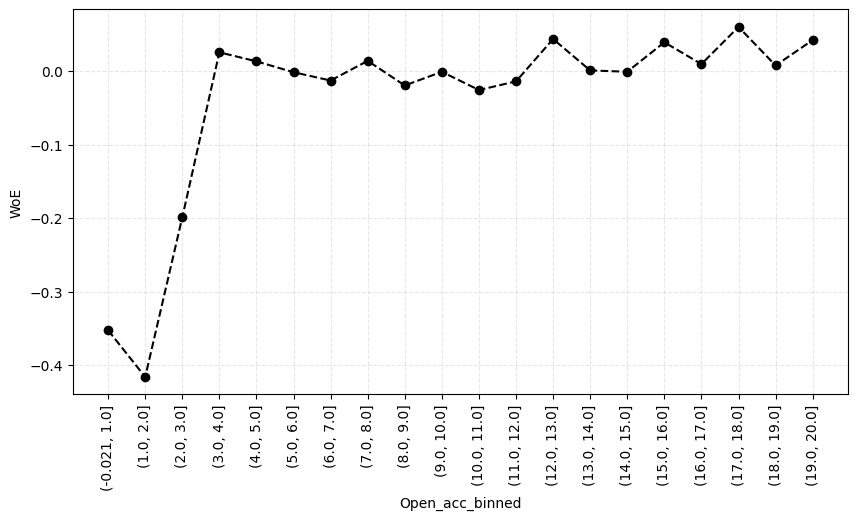

In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name='open_acc_binned',
    target_column_name=target_variable,
    sort_by_woe=False
)
display(woe_df)

# Convert the index (intervals) to strings for plotting
woe_df.index = woe_df.index.astype(str)

plot_woe_by_category(woe_df, rotate = True)

In [ ]:
# Use sensible boundaries that cover our data range
boundaries = [0, 2, 10, 20]


#labels = ['0-2', '3', '10 +']

# Create bins
df_train_mod['open_acc_binned'] = pd.cut(
    df_train_mod['open_acc'],
    bins=boundaries,
    #labels=labels,
    include_lowest=True
)

print("Bins created and their counts:")
bin_counts = df_train_mod['open_acc_binned'].value_counts().sort_index()
print(bin_counts)

Bins created and their counts:
open_acc_binned
(-0.001, 2.0]      1553
(2.0, 10.0]      189338
(10.0, 20.0]     182137
Name: count, dtype: int64


/tmp/ipython-input-1485944256.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix = pd.pivot_table(


,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
open_acc_binned,,,,,,,,
"(-0.001, 2.0]",1311.5,242.5,1554.0,0.003947,0.005947,-0.409898,0.000820,0.000896
"(2.0, 10.0]",168525.5,20813.5,189339.0,0.507217,0.510441,-0.006338,0.000020,0.000896
"(10.0, 20.0]",162418.5,19719.5,182138.0,0.488836,0.483611,0.010746,0.000056,0.000896


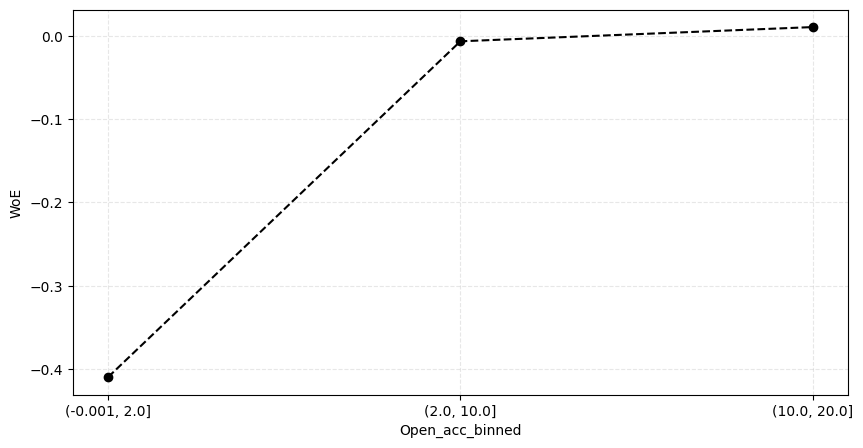

In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name='open_acc_binned',
    target_column_name=target_variable,
    sort_by_woe=False
)
display(woe_df)

# Convert the index (intervals) to strings for plotting
woe_df.index = woe_df.index.astype(str)

plot_woe_by_category(woe_df, rotate = False)

In [ ]:
df_test_mod[variable].describe()

,open_acc
count,93249.000000
mean,11.195841
std,4.971985
min,0.000000
25%,8.000000
50%,10.000000
75%,14.000000
max,62.000000


In [ ]:
df_test_mod[variable] = df_test_mod[variable].fillna(df_test_mod[variable].max())

df_test_mod[variable] = np.where(df_test_mod[variable] > 20, 20, df_test_mod[variable])

df_test_mod['open_acc_binned'] = pd.cut(
    df_test_mod['open_acc'],
    bins=boundaries,
    #labels=labels,
    include_lowest=True
)

print("Bins created and their counts:")
bin_counts = df_test_mod['open_acc_binned'].value_counts().sort_index()
print(bin_counts)

Bins created and their counts:
open_acc_binned
(-0.001, 2.0]      386
(2.0, 10.0]      47157
(10.0, 20.0]     45714
Name: count, dtype: int64


In [ ]:
variable = "pub_rec"
df_train_mod[variable] = df_train_mod[variable].fillna(df_train_mod[variable].min())
print(f"{df_train_mod[variable].isnull().sum():,} missing rows!\n\n")
print(df_train_mod[variable].describe(percentiles=[0.25, 0.75, 0.90, 0.95, 0.999]))

0 missing rows!


count    373028.000000
mean          0.160854
std           0.514394
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
90%           1.000000
95%           1.000000
99.9%         5.000000
max          63.000000
Name: pub_rec, dtype: float64


The `pub_rec` variable is highly skewed. To reduce the influence of outliers, we will winsorize it at the 95th percentile (value = 5).

In [ ]:
df_train_mod[variable] = np.where(df_train_mod[variable] > 5, 5, df_train_mod[variable])

<Axes: xlabel='pub_rec', ylabel='Count'>

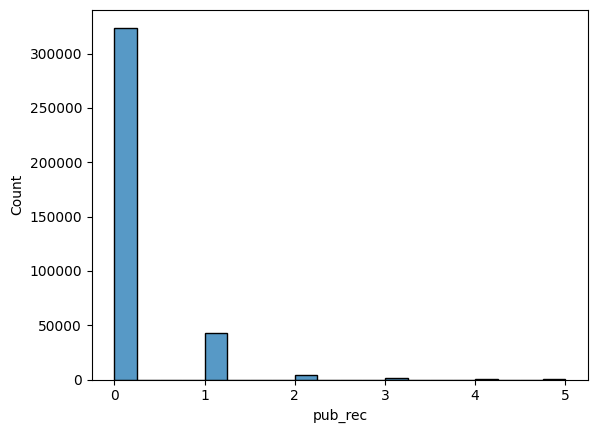

In [ ]:
sns.histplot(df_train_mod[variable])

In [ ]:
# Let pandas automatically create equal bins
df_train_mod['pub_rec_binned'] = pd.cut(
    df_train_mod['pub_rec'],
    bins=5,
    include_lowest=True
)

print("Automatic equal bins:")
print(df_train_mod['pub_rec_binned'].value_counts().sort_index())

Automatic equal bins:
pub_rec_binned
(-0.006, 1.0]    366374
(1.0, 2.0]         4505
(2.0, 3.0]         1282
(3.0, 4.0]          425
(4.0, 5.0]          442
Name: count, dtype: int64


/tmp/ipython-input-1485944256.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix = pd.pivot_table(


,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
pub_rec_binned,,,,,,,,
"(-0.006, 1.0]",326215.5,40159.5,366375.0,0.981818,0.984869,-0.003102,0.000009,0.000918
"(1.0, 2.0]",4059.5,446.5,4506.0,0.012218,0.010950,0.109574,0.000139,0.000918
"(2.0, 3.0]",1182.5,100.5,1283.0,0.003559,0.002465,0.367427,0.000402,0.000918
"(3.0, 4.0]",383.5,42.5,426.0,0.001154,0.001042,0.102034,0.000011,0.000918
"(4.0, 5.0]",415.5,27.5,443.0,0.001251,0.000674,0.617495,0.000356,0.000918


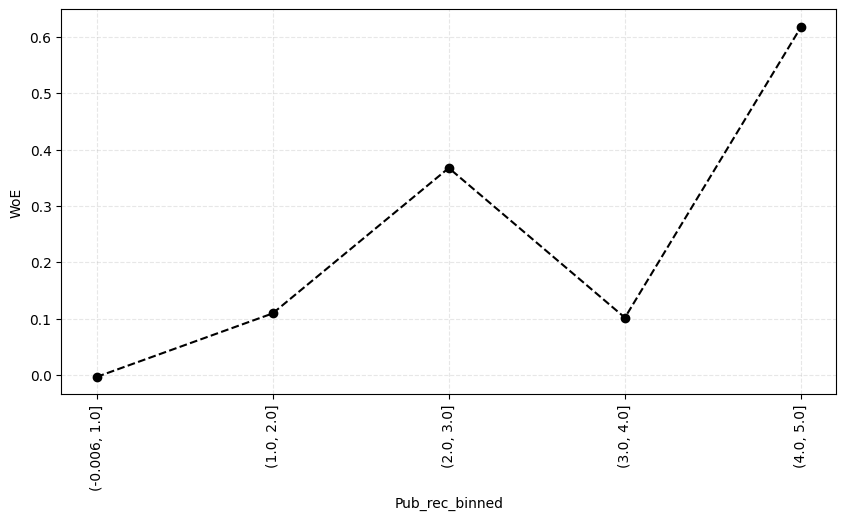

In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name='pub_rec_binned',
    target_column_name=target_variable,
    sort_by_woe=False
)
display(woe_df)

# Convert the index (intervals) to strings for plotting
woe_df.index = woe_df.index.astype(str)

plot_woe_by_category(woe_df, rotate = True)

In [ ]:
# Use sensible boundaries that cover our data range
boundaries = [0,
              1,
              3,
              5]


#labels = ['0', '1', '2', '3-4', '5', '6 +']

# Create bins
df_train_mod['pub_rec_binned'] = pd.cut(
    df_train_mod['pub_rec'],
    bins=boundaries,
    #labels=labels,
    include_lowest=True
)

print("Bins created and their counts:")
bin_counts = df_train_mod['open_acc_binned'].value_counts().sort_index()
print(bin_counts)

Bins created and their counts:
open_acc_binned
(-0.001, 2.0]      1553
(2.0, 10.0]      189338
(10.0, 20.0]     182137
Name: count, dtype: int64


/tmp/ipython-input-1485944256.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix = pd.pivot_table(


,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
pub_rec_binned,,,,,,,,
"(-0.001, 1.0]",326215.5,40159.5,366375.0,0.981821,0.984893,-0.003124,0.000010,0.000636
"(1.0, 3.0]",5241.5,546.5,5788.0,0.015776,0.013403,0.163006,0.000387,0.000636
"(3.0, 5.0]",798.5,69.5,868.0,0.002403,0.001704,0.343585,0.000240,0.000636


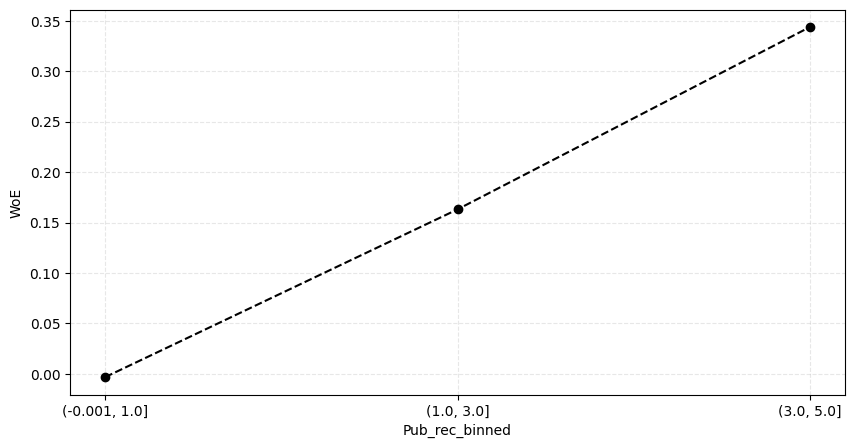

In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name='pub_rec_binned',
    target_column_name=target_variable,
    sort_by_woe=False
)
display(woe_df)

# Convert the index (intervals) to strings for plotting
woe_df.index = woe_df.index.astype(str)

plot_woe_by_category(woe_df, rotate = False)

In [ ]:
df_test_mod[variable] = df_test_mod[variable].fillna(df_test_mod[variable].min())

df_test_mod[variable] = np.where(df_test_mod[variable] > 5, 5, df_test_mod[variable])

df_test_mod['pub_rec_binned'] = pd.cut(
    df_test_mod['pub_rec'],
    bins=boundaries,
    #labels=labels,
    include_lowest=True
)

print("Bins created and their counts:")
bin_counts = df_test_mod['pub_rec_binned'].value_counts().sort_index()
print(bin_counts)

Bins created and their counts:
pub_rec_binned
(-0.001, 1.0]    91599
(1.0, 3.0]        1448
(3.0, 5.0]         210
Name: count, dtype: int64


In [ ]:
variable = "total_acc"

print(f"{df_train_mod[variable].isnull().sum():,} missing rows!\n\n")
df_train_mod[variable] = df_train_mod[variable].fillna(df_train_mod[variable].min())
print(df_train_mod[variable].describe(percentiles=[0.25, 0.75, 0.90, 0.95, 0.999]))

21 missing rows!


count    373028.000000
mean         25.073954
std          11.617378
min           1.000000
25%          17.000000
50%          23.000000
75%          32.000000
90%          41.000000
95%          47.000000
99.9%        72.000000
max         156.000000
Name: total_acc, dtype: float64


The total_acc variable is highly skewed. To limit the impact of extreme values, we will winsorize it at the 95th percentile (value = 47).

In [ ]:
df_train_mod[variable] = np.where(df_train_mod[variable] > 47, 47, df_train_mod[variable])

<Axes: xlabel='total_acc', ylabel='Count'>

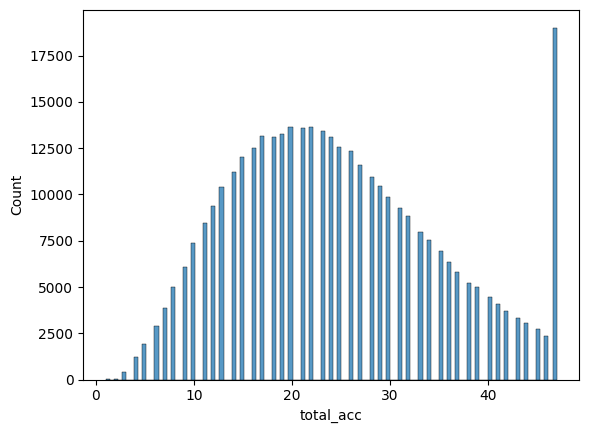

In [ ]:
sns.histplot(df_train_mod[variable])

In [ ]:
# Let pandas automatically create equal bins
df_train_mod['total_acc_binned'] = pd.cut(
    df_train_mod['total_acc'],
    bins=30,
    include_lowest=True
)

print("Automatic equal bins:")
print(df_train_mod['total_acc_binned'].value_counts().sort_index())

Automatic equal bins:
total_acc_binned
(0.953, 2.533]         84
(2.533, 4.067]       1588
(4.067, 5.6]         1899
(5.6, 7.133]         6790
(7.133, 8.667]       5021
(8.667, 10.2]       13434
(10.2, 11.733]       8481
(11.733, 13.267]    19761
(13.267, 14.8]      11196
(14.8, 16.333]      24547
(16.333, 17.867]    13161
(17.867, 19.4]      26390
(19.4, 20.933]      13640
(20.933, 22.467]    27257
(22.467, 24.0]      26559
(24.0, 25.533]      12558
(25.533, 27.067]    23912
(27.067, 28.6]      10927
(28.6, 30.133]      20311
(30.133, 31.667]     9269
(31.667, 33.2]      16774
(33.2, 34.733]       7516
(34.733, 36.267]    13258
(36.267, 37.8]       5828
(37.8, 39.333]      10177
(39.333, 40.867]     4443
(40.867, 42.4]       7775
(42.4, 43.933]       3311
(43.933, 45.467]     5791
(45.467, 47.0]      21370
Name: count, dtype: int64


/tmp/ipython-input-1485944256.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix = pd.pivot_table(


,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
total_acc_binned,,,,,,,,
"(0.953, 2.533]",67.5,17.5,85.0,0.000203,0.000429,-0.747606,1.688756e-04,0.008003
"(2.533, 4.067]",1331.5,257.5,1589.0,0.004007,0.006313,-0.454491,1.047911e-03,0.008003
"(4.067, 5.6]",1636.5,263.5,1900.0,0.004925,0.006460,-0.271271,4.163595e-04,0.008003
"(5.6, 7.133]",5891.5,899.5,6791.0,0.017731,0.022053,-0.218106,9.425212e-04,0.008003
"(7.133, 8.667]",4389.5,632.5,5022.0,0.013211,0.015507,-0.160242,3.679078e-04,0.008003
"(8.667, 10.2]",11781.5,1653.5,13435.0,0.035458,0.040538,-0.133896,6.802159e-04,0.008003
"(10.2, 11.733]",7481.5,1000.5,8482.0,0.022516,0.024529,-0.085599,1.722489e-04,0.008003
"(11.733, 13.267]",17385.5,2376.5,19762.0,0.052324,0.058263,-0.107525,6.386634e-04,0.008003
"(13.267, 14.8]",9886.5,1310.5,11197.0,0.029755,0.032129,-0.076771,1.822739e-04,0.008003


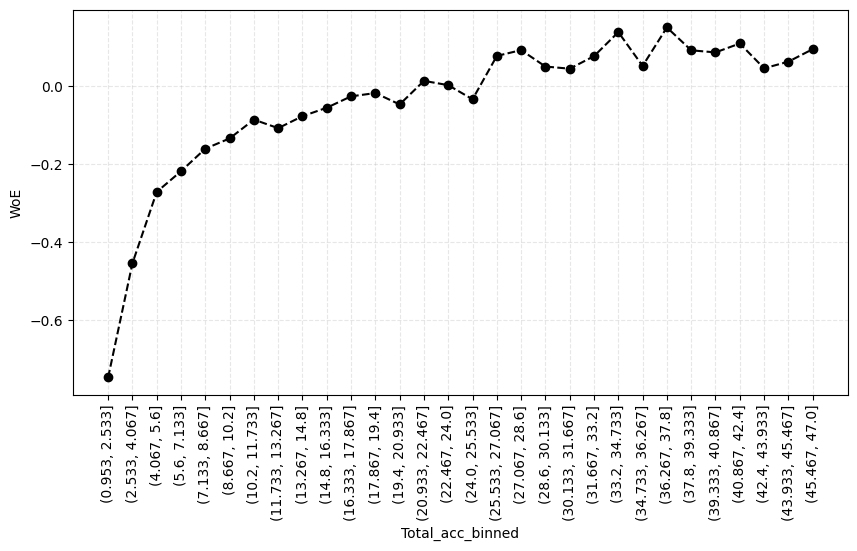

In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name='total_acc_binned',
    target_column_name=target_variable,
    sort_by_woe=False
)
display(woe_df)

# Convert the index (intervals) to strings for plotting
woe_df.index = woe_df.index.astype(str)

plot_woe_by_category(woe_df, rotate = True)

In [ ]:
# Use sensible boundaries that cover our data range
boundaries = [1,
              25,
              47]


#labels = ['0', '1', '2', '3-4', '5', '6 +']

# Create bins
df_train_mod['total_acc_binned'] = pd.cut(
    df_train_mod['total_acc'],
    bins=boundaries,
    #labels=labels,
    include_lowest=True
)

print("Bins created and their counts:")
bin_counts = df_train_mod['total_acc_binned'].value_counts().sort_index()
print(bin_counts)

Bins created and their counts:
total_acc_binned
(0.999, 25.0]    212366
(25.0, 47.0]     160662
Name: count, dtype: int64


/tmp/ipython-input-1485944256.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix = pd.pivot_table(


,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
total_acc_binned,,,,,,,,
"(0.999, 25.0]",187932.5,24434.5,212367.0,0.565627,0.599252,-0.057747,0.001942,0.004651
"(25.0, 47.0]",144322.5,16340.5,160663.0,0.434373,0.400748,0.080570,0.002709,0.004651


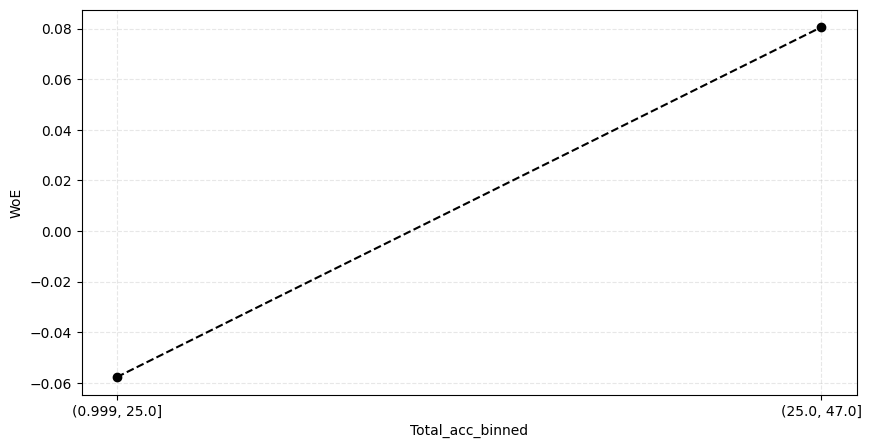

In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name='total_acc_binned',
    target_column_name=target_variable,
    sort_by_woe=False
)
display(woe_df)

# Convert the index (intervals) to strings for plotting
woe_df.index = woe_df.index.astype(str)

plot_woe_by_category(woe_df, rotate = False)

In [ ]:
df_test_mod[variable] = df_test_mod[variable].fillna(df_test_mod[variable].min())

df_test_mod[variable] = np.where(df_test_mod[variable] > 47, 47, df_test_mod[variable])

df_test_mod['total_acc_binned'] = pd.cut(
    df_test_mod['total_acc'],
    bins=boundaries,
    #labels=labels,
    include_lowest=True
)

print("Bins created and their counts:")
bin_counts = df_test_mod['total_acc_binned'].value_counts().sort_index()
print(bin_counts)

Bins created and their counts:
total_acc_binned
(0.999, 25.0]    53152
(25.0, 47.0]     40105
Name: count, dtype: int64


In [ ]:
variable = "dti"

print(f"{df_train_mod[variable].isnull().sum():,} missing rows!\n\n")
df_train_mod[variable] = df_train_mod[variable].fillna(df_train_mod[variable].max())
print(df_train_mod[variable].describe(percentiles=[0.25, 0.75, 0.90, 0.95, 0.999]))

0 missing rows!


count    373028.000000
mean         17.217185
std           7.851843
min           0.000000
25%          11.360000
50%          16.870000
75%          22.790000
90%          28.000000
95%          30.760000
99.9%        39.200000
max          39.990000
Name: dti, dtype: float64


<Axes: xlabel='dti', ylabel='Count'>

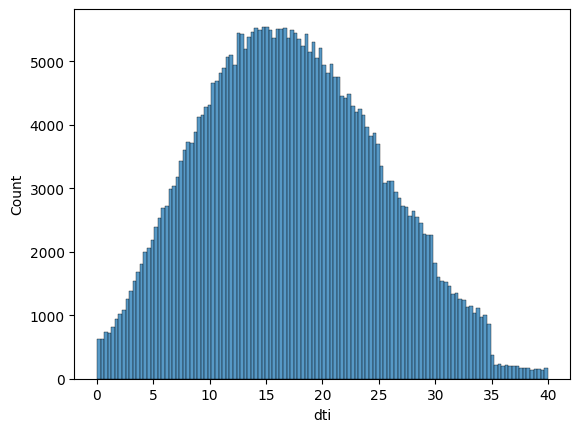

In [ ]:
sns.histplot(df_train_mod[variable])

In [ ]:
# Let pandas automatically create equal bins
df_train_mod['dti_binned'] = pd.cut(
    df_train_mod['dti'],
    bins=20,
    include_lowest=True
)

print("Automatic equal bins:")
print(df_train_mod['dti_binned'].value_counts().sort_index())

Automatic equal bins:
dti_binned
(-0.041, 2.0]        4711
(2.0, 3.999]         8732
(3.999, 5.998]      14260
(5.998, 7.998]      20040
(7.998, 9.998]      25293
(9.998, 11.997]     30206
(11.997, 13.997]    33528
(13.997, 15.996]    34730
(15.996, 17.996]    34227
(17.996, 19.995]    33090
(19.995, 21.995]    30051
(21.995, 23.994]    26659
(23.994, 25.994]    22379
(25.994, 27.993]    17762
(27.993, 29.992]    14910
(29.992, 31.992]     9347
(31.992, 33.992]     7306
(33.992, 35.991]     3599
(35.991, 37.991]     1229
(37.991, 39.99]       969
Name: count, dtype: int64


/tmp/ipython-input-1485944256.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix = pd.pivot_table(


,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
dti_binned,,,,,,,,
"(-0.041, 2.0]",4240.5,471.5,4712.0,0.012762,0.011561,0.098877,0.000119,0.026166
"(2.0, 3.999]",7961.5,771.5,8733.0,0.023961,0.018917,0.236396,0.001193,0.026166
"(3.999, 5.998]",13015.5,1245.5,14261.0,0.039172,0.030539,0.248964,0.002149,0.026166
"(5.998, 7.998]",18299.5,1741.5,20041.0,0.055075,0.042701,0.254487,0.003149,0.026166
"(7.998, 9.998]",22986.5,2307.5,25294.0,0.069181,0.056579,0.201102,0.002534,0.026166
"(9.998, 11.997]",27362.5,2844.5,30207.0,0.082352,0.069745,0.166146,0.002094,0.026166
"(11.997, 13.997]",30231.5,3297.5,33529.0,0.090986,0.080853,0.118080,0.001197,0.026166
"(13.997, 15.996]",31250.5,3480.5,34731.0,0.094053,0.085340,0.097219,0.000847,0.026166
"(15.996, 17.996]",30499.5,3728.5,34228.0,0.091793,0.091421,0.004064,0.000002,0.026166


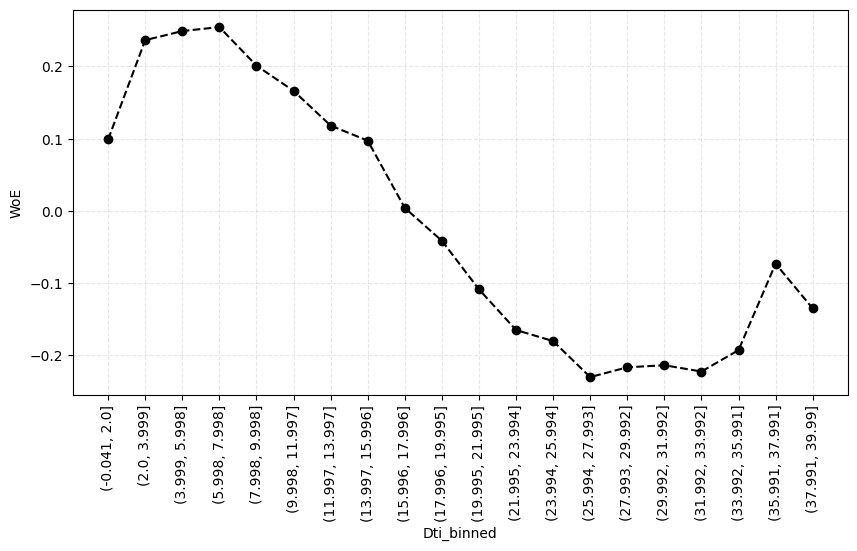

In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name='dti_binned',
    target_column_name=target_variable,
    sort_by_woe=False
)
display(woe_df)

# Convert the index (intervals) to strings for plotting
woe_df.index = woe_df.index.astype(str)

plot_woe_by_category(woe_df, rotate = True)

In [ ]:
# Use sensible boundaries that cover our data range
boundaries = [0,
    8,
    12,
    16,
    18,
    20,
    22,
    27,
    40]


#labels = ['0', '1', '2', '3-4', '5', '6 +']

# Create bins
df_train_mod['dti_binned'] = pd.cut(
    df_train_mod['dti'],
    bins=boundaries,
    #labels=labels,
    include_lowest=True
)

print("Bins created and their counts:")
bin_counts = df_train_mod['dti_binned'].value_counts().sort_index()
print(bin_counts)

Bins created and their counts:
dti_binned
(-0.001, 8.0]    47857
(8.0, 12.0]      55690
(12.0, 16.0]     68135
(16.0, 18.0]     34331
(18.0, 20.0]     33004
(20.0, 22.0]     29994
(22.0, 27.0]     58351
(27.0, 40.0]     45666
Name: count, dtype: int64


/tmp/ipython-input-1485944256.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix = pd.pivot_table(


,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
dti_binned,,,,,,,,
"(-0.001, 8.0]",43615.5,4242.5,47858.0,0.131270,0.104039,0.232491,6.330965e-03,0.025635
"(8.0, 12.0]",50525.5,5165.5,55691.0,0.152067,0.126674,0.182707,4.639552e-03,0.025635
"(12.0, 16.0]",61363.5,6772.5,68136.0,0.184686,0.166082,0.106176,1.975306e-03,0.025635
"(16.0, 18.0]",30584.5,3747.5,34332.0,0.092050,0.091900,0.001635,2.459723e-07,0.025635
"(18.0, 20.0]",29274.5,3730.5,33005.0,0.088108,0.091483,-0.037594,1.268971e-04,0.025635
"(20.0, 22.0]",26382.5,3612.5,29995.0,0.079404,0.088589,-0.109468,1.005551e-03,0.025635
"(22.0, 27.0]",50855.5,7496.5,58352.0,0.153060,0.183837,-0.183217,5.638797e-03,0.025635
"(27.0, 40.0]",39656.5,6010.5,45667.0,0.119355,0.147396,-0.211022,5.917296e-03,0.025635


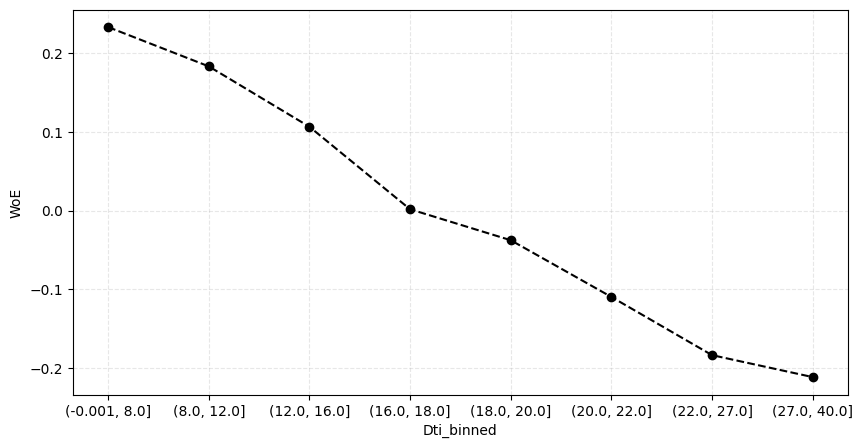

In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name='dti_binned',
    target_column_name=target_variable,
    sort_by_woe=False
)
display(woe_df)

# Convert the index (intervals) to strings for plotting
woe_df.index = woe_df.index.astype(str)

plot_woe_by_category(woe_df, rotate = False)

In [ ]:
df_test_mod[variable] = df_test_mod[variable].fillna(df_test_mod[variable].max())

df_test_mod['dti_binned'] = pd.cut(
    df_test_mod['dti'],
    bins=boundaries,
    #labels=labels,
    include_lowest=True
)

print("Bins created and their counts:")
bin_counts = df_test_mod['dti_binned'].value_counts().sort_index()
print(bin_counts)

Bins created and their counts:
dti_binned
(-0.001, 8.0]    11981
(8.0, 12.0]      13842
(12.0, 16.0]     17088
(16.0, 18.0]      8530
(18.0, 20.0]      8253
(20.0, 22.0]      7646
(22.0, 27.0]     14459
(27.0, 40.0]     11458
Name: count, dtype: int64


In [ ]:
variable = "total_rev_hi_lim"

print(f"{df_train_mod[variable].isnull().sum():,} missing rows!\n\n")
df_train_mod[variable] = df_train_mod[variable].fillna(df_train_mod['funded_amnt'])
print(df_train_mod[variable].describe(percentiles=[0.25, 0.75, 0.90, 0.95, 0.999]).round())

56,264 missing rows!


count     373028.0
mean       27599.0
std        36730.0
min            0.0
25%        11600.0
50%        20100.0
75%        34600.0
90%        54600.0
95%        72300.0
99.9%     295126.0
max      9999999.0
Name: total_rev_hi_lim, dtype: float64


This variable exhibits a highly skewed distribution. To reduce the influence of extreme values, we will winsorize it.

In [ ]:
df_train_mod[variable] = np.where(df_train_mod[variable] > 100_000, 100_000, df_train_mod[variable])

<Axes: xlabel='total_rev_hi_lim', ylabel='Count'>

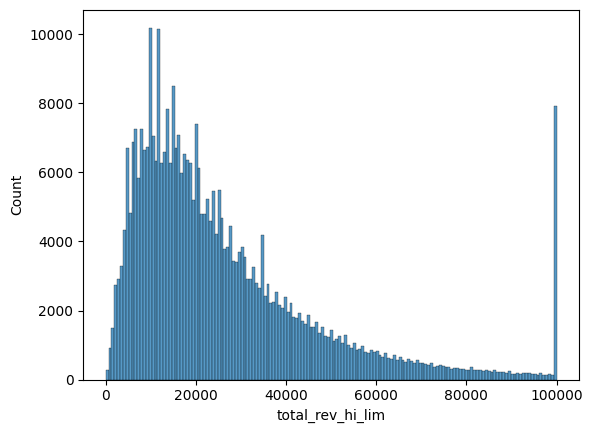

In [ ]:
sns.histplot(df_train_mod[variable])

In [ ]:
# Let pandas automatically create equal bins
df_train_mod['total_rev_hi_lim_binned'] = pd.cut(
    df_train_mod['total_rev_hi_lim'],
    bins=30,
    include_lowest=True
)

print("Automatic equal bins:")
print(df_train_mod['total_rev_hi_lim_binned'].value_counts().sort_index())

Automatic equal bins:
total_rev_hi_lim_binned
(-100.001, 3333.333]       9124
(3333.333, 6666.667]      28099
(6666.667, 10000.0]       40116
(10000.0, 13333.333]      37316
(13333.333, 16666.667]    37324
(16666.667, 20000.0]      34369
(20000.0, 23333.333]      26558
(23333.333, 26666.667]    24512
(26666.667, 30000.0]      20616
(30000.0, 33333.333]      16135
(33333.333, 36666.667]    15056
(36666.667, 40000.0]      12174
(40000.0, 43333.333]      10054
(43333.333, 46666.667]     8667
(46666.667, 50000.0]       7381
(50000.0, 53333.333]       6115
(53333.333, 56666.667]     5092
(56666.667, 60000.0]       4441
(60000.0, 63333.333]       3656
(63333.333, 66666.667]     3139
(66666.667, 70000.0]       2817
(70000.0, 73333.333]       2290
(73333.333, 76666.667]     2002
(76666.667, 80000.0]       1663
(80000.0, 83333.333]       1507
(83333.333, 86666.667]     1312
(86666.667, 90000.0]       1148
(90000.0, 93333.333]        928
(93333.333, 96666.667]      870
(96666.667, 100000.0]     

/tmp/ipython-input-1485944256.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix = pd.pivot_table(


,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
total_rev_hi_lim_binned,,,,,,,,
"(-100.001, 3333.333]",7817.5,1307.5,9125.0,0.023528,0.032055,-0.309285,0.002637,0.042912
"(3333.333, 6666.667]",24504.5,3595.5,28100.0,0.073749,0.088149,-0.178359,0.002568,0.042912
"(6666.667, 10000.0]",35133.5,4983.5,40117.0,0.105738,0.122178,-0.144510,0.002376,0.042912
"(10000.0, 13333.333]",32864.5,4452.5,37317.0,0.098909,0.109159,-0.098605,0.001011,0.042912
"(13333.333, 16666.667]",32785.5,4539.5,37325.0,0.098672,0.111292,-0.120363,0.001519,0.042912
"(16666.667, 20000.0]",30253.5,4116.5,34370.0,0.091051,0.100922,-0.102924,0.001016,0.042912
"(20000.0, 23333.333]",23605.5,2953.5,26559.0,0.071043,0.072409,-0.019044,0.000026,0.042912
"(23333.333, 26666.667]",21738.5,2774.5,24513.0,0.065424,0.068021,-0.038918,0.000101,0.042912
"(26666.667, 30000.0]",18403.5,2213.5,20617.0,0.055387,0.054267,0.020433,0.000023,0.042912


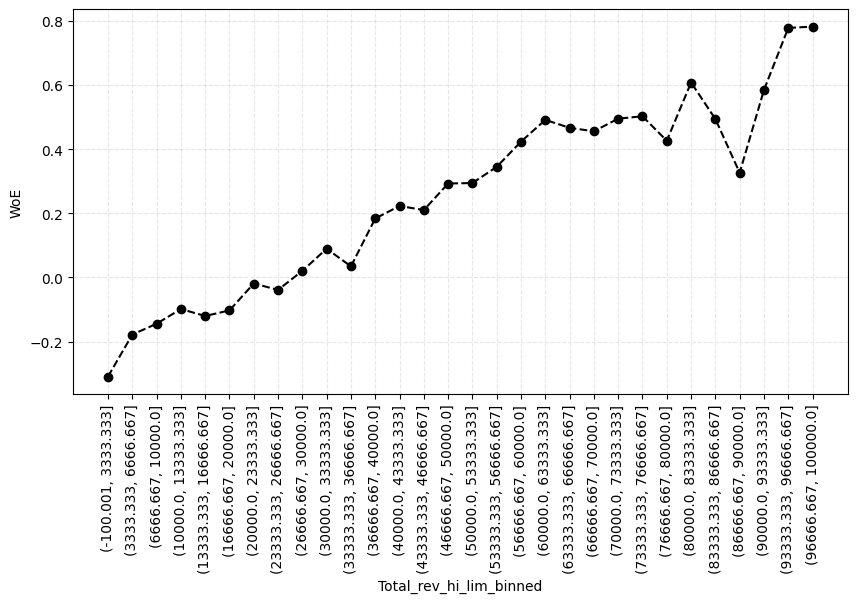

In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name='total_rev_hi_lim_binned',
    target_column_name=target_variable,
    sort_by_woe=False
)
display(woe_df)

# Convert the index (intervals) to strings for plotting
woe_df.index = woe_df.index.astype(str)

plot_woe_by_category(woe_df, rotate = True)

In [ ]:
# Use sensible boundaries that cover our data range
boundaries = [0,
    6_000,
    20_000,
    36_000,
    46_000,
    56_000,
    80_000,
    100_000]


#labels = ['0', '1', '2', '3-4', '5', '6 +']

# Create bins
df_train_mod['total_rev_hi_lim_binned'] = pd.cut(
    df_train_mod['total_rev_hi_lim'],
    bins=boundaries,
    #labels=labels,
    include_lowest=True
)

print("Bins created and their counts:")
bin_counts = df_train_mod['total_rev_hi_lim_binned'].value_counts().sort_index()
print(bin_counts)

Bins created and their counts:
total_rev_hi_lim_binned
(-0.001, 6000.0]        32123
(6000.0, 20000.0]      154225
(20000.0, 36000.0]     100573
(36000.0, 46000.0]      31741
(46000.0, 56000.0]      19154
(56000.0, 80000.0]      20900
(80000.0, 100000.0]     14312
Name: count, dtype: int64


/tmp/ipython-input-1485944256.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix = pd.pivot_table(


,Good,Bad,Total,% Good,% Bad,WoE,IV_individual,IV_total
total_rev_hi_lim_binned,,,,,,,,
"(-0.001, 6000.0]",27857.5,4266.5,32124.0,0.083843,0.104629,-0.221471,0.004603,0.041633
"(6000.0, 20000.0]",135499.5,18726.5,154226.0,0.407815,0.459236,-0.118751,0.006106,0.041633
"(20000.0, 36000.0]",89614.5,10959.5,100574.0,0.269714,0.268763,0.003531,0.000003,0.041633
"(36000.0, 46000.0]",28862.5,2879.5,31742.0,0.086868,0.070615,0.207147,0.003367,0.041633
"(46000.0, 56000.0]",17543.5,1611.5,19155.0,0.052801,0.039519,0.289738,0.003848,0.041633
"(56000.0, 80000.0]",19404.5,1496.5,20901.0,0.058402,0.036699,0.464596,0.010083,0.041633
"(80000.0, 100000.0]",13475.5,837.5,14313.0,0.040557,0.020538,0.680427,0.013622,0.041633


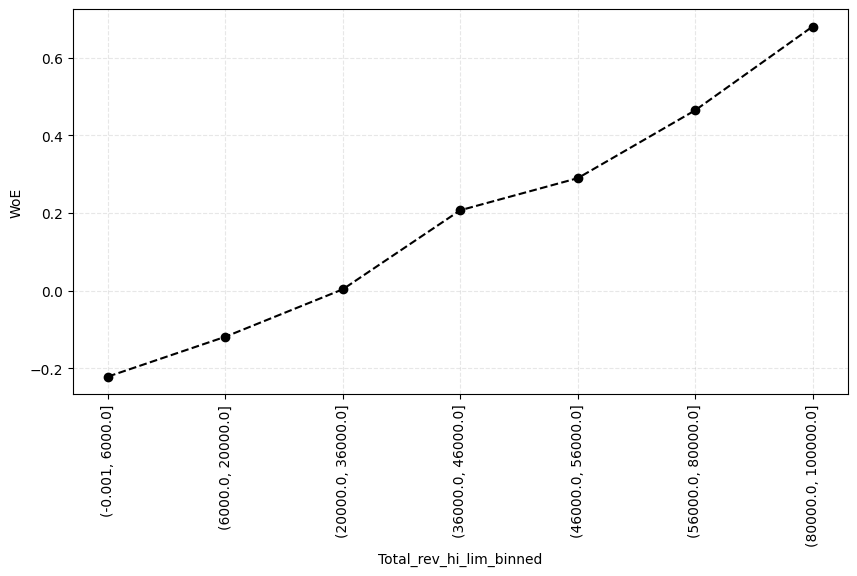

In [ ]:
woe_df = compute_woe(
    df=df_train_mod,
    id_column_name="id",
    feature_column_name='total_rev_hi_lim_binned',
    target_column_name=target_variable,
    sort_by_woe=False
)
display(woe_df)

# Convert the index (intervals) to strings for plotting
woe_df.index = woe_df.index.astype(str)

plot_woe_by_category(woe_df, rotate = True)

In [ ]:
df_test_mod[variable] = df_test_mod[variable].fillna(df_test_mod['funded_amnt'].max())

df_test_mod[variable] = np.where(df_test_mod[variable] > 100_000, 100_000, df_test_mod[variable])

df_test_mod['total_rev_hi_lim_binned'] = pd.cut(
    df_test_mod['total_rev_hi_lim'],
    bins=boundaries,
    #labels=labels,
    include_lowest=True
)

print("Bins created and their counts:")
bin_counts = df_test_mod['total_rev_hi_lim_binned'].value_counts().sort_index()
print(bin_counts)

Bins created and their counts:
total_rev_hi_lim_binned
(-0.001, 6000.0]        4076
(6000.0, 20000.0]      30125
(20000.0, 36000.0]     37525
(36000.0, 46000.0]      7911
(46000.0, 56000.0]      4845
(56000.0, 80000.0]      5195
(80000.0, 100000.0]     3580
Name: count, dtype: int64


## **Modeling**

In [ ]:
selected_columns = [
    'grade',
    'home_ownership',
    'addr_state',
    'verification_status',
    'purpose',
    'initial_list_status',
    'term',
    'emp_length',
    'months_since_issue_date_binned',
    'int_rate_binned',
    'months_since_earliest_cr_line_binned',
    'annual_inc_binned',
    'delinq_2yrs_binned',
    'inq_last_6mths_binned',
    'open_acc_binned',
    'pub_rec_binned',
    'total_acc_binned',
    'dti_binned',
    'total_rev_hi_lim_binned'
]

In [ ]:
df_train_mod[selected_columns].isnull().sum()

,0
grade,0
home_ownership,0
addr_state,0
verification_status,0
purpose,0
initial_list_status,0
term,0
emp_length,0
months_since_issue_date_binned,0
int_rate_binned,0


In [ ]:
df_test_mod[selected_columns].isnull().sum()

,0
grade,0
home_ownership,0
addr_state,0
verification_status,0
purpose,0
initial_list_status,0
term,0
emp_length,0
months_since_issue_date_binned,0
int_rate_binned,0


In [ ]:
X_train = df_train_mod[selected_columns]
X_test = df_test_mod[selected_columns]

y_train = df_train_mod['default']
y_test = df_test_mod['default']

In [ ]:
X_train.columns.equals(X_test.columns)

True

We used One-Hot Encoding (OHE) to convert all binned categorical variables into dummy variables. For each feature, we dropped the category with the lowest WoE (i.e., the riskiest group) as the reference category. This ensures all other dummy variables are measured relative to the riskiest group, which:

- Supports regulatory compliance – each variable has a clear baseline category.

- Improves interpretability – coefficients show the effect of being in a safer category compared to the riskiest one.

- Maintains scorecard consistency – avoids multicollinearity and produces monotonic, transparent relationships between features and default risk.

In [ ]:
reference_categories = {
    "grade": "G",
    "home_ownership": "NONE_OTHER_RENT_ANY",
    "addr_state": "NV_ND_ME_NE_IA",
    "verification_status": "Verified",
    "purpose": "educational_small_business",
    "initial_list_status": "f",
    "term": np.int64(60),
    "emp_length": "<1y",
    "months_since_issue_date_binned": Interval(63.0, 84.0, closed='right'),
    "int_rate_binned": Interval(20.5, 27.0, closed='right'),
    "months_since_earliest_cr_line_binned": Interval(71.999, 140.0, closed='right'),
    "annual_inc_binned": Interval(-0.001, 20000.0, closed='right'),
    "delinq_2yrs_binned": "5-8",
    "inq_last_6mths_binned": "6 +",
    "open_acc_binned": Interval(-0.001, 2.0, closed='right'),
    "pub_rec_binned": Interval(-0.001, 1.0, closed='right'),
    "total_acc_binned": Interval(0.999, 25.0, closed='right'),
    "dti_binned": Interval(27.0, 40.0, closed='right'),
    "total_rev_hi_lim_binned": Interval(-0.001, 6000.0, closed='right')
}

In [ ]:
encoder = OneHotEncoder(
    drop=[reference_categories[col] for col in selected_columns],
    handle_unknown='ignore',
    sparse_output=False
)

In [ ]:
for col in selected_columns:
    if reference_categories[col] not in X_train[col].unique():
        print("WARNING:", col, "→ reference not in training data")

In [ ]:
X_train_encoded = encoder.fit_transform(X_train)
X_test_encoded = encoder.transform(X_test)

In [ ]:
feature_names = encoder.get_feature_names_out(selected_columns)

In [ ]:
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=feature_names, index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=feature_names, index=X_test.index)

In [ ]:
X_train_encoded_df.head()

,grade_A,grade_B,grade_C,grade_D,grade_E,grade_F,home_ownership_MORTGAGE,home_ownership_OWN,addr_state_AL_OK_LA,addr_state_CA,addr_state_CT,addr_state_FL,addr_state_HI,addr_state_IL,addr_state_IN_OR_WA_GA,addr_state_KY_RI_ID,addr_state_MD_NJ_VA_NC_NM,addr_state_MN_MA_SD,addr_state_MO,addr_state_MS_AK_MT_VT,addr_state_NH_WY_DC,addr_state_NY,addr_state_PA_AR_OH_UT,addr_state_TN_AZ_MI,addr_state_TX,addr_state_WI_DE,addr_state_WV_KS_CO_SC,verification_status_Not Verified,verification_status_Source Verified,purpose_car,purpose_credit_card,purpose_debt_consolidation,purpose_major_purchase_home_improvement,purpose_medical,purpose_other,purpose_renewable_energy_house_moving,purpose_vacation_wedding,initial_list_status_w,term_36,emp_length_10+y,emp_length_1y,emp_length_2-4y,emp_length_5-6y,emp_length_7-9y,"months_since_issue_date_binned_(34.999, 39.0]","months_since_issue_date_binned_(39.0, 42.0]","months_since_issue_date_binned_(42.0, 45.0]","months_since_issue_date_binned_(45.0, 48.0]","months_since_issue_date_binned_(48.0, 51.0]","months_since_issue_date_binned_(51.0, 54.0]","months_since_issue_date_binned_(54.0, 63.0]","months_since_issue_date_binned_(84.0, 127.0]","int_rate_binned_(4.999, 6.0]","int_rate_binned_(6.0, 7.5]","int_rate_binned_(7.5, 8.9]","int_rate_binned_(8.9, 9.5]","int_rate_binned_(9.5, 10.2]","int_rate_binned_(10.2, 13.7]","int_rate_binned_(13.7, 15.7]","int_rate_binned_(15.7, 17.1]","int_rate_binned_(17.1, 20.5]","months_since_earliest_cr_line_binned_(140.0, 220.0]","months_since_earliest_cr_line_binned_(220.0, 280.0]","months_since_earliest_cr_line_binned_(280.0, 360.0]","months_since_earliest_cr_line_binned_(360.0, 890.0]","annual_inc_binned_(20000.0, 30000.0]","annual_inc_binned_(30000.0, 40000.0]","annual_inc_binned_(40000.0, 50000.0]","annual_inc_binned_(50000.0, 60000.0]","annual_inc_binned_(60000.0, 70000.0]","annual_inc_binned_(70000.0, 80000.0]","annual_inc_binned_(80000.0, 90000.0]","annual_inc_binned_(90000.0, 100000.0]","annual_inc_binned_(100000.0, 120000.0]","annual_inc_binned_(120000.0, 141000.0]",delinq_2yrs_binned_0-1,delinq_2yrs_binned_2-4,inq_last_6mths_binned_0,inq_last_6mths_binned_1,inq_last_6mths_binned_2,inq_last_6mths_binned_3-4,inq_last_6mths_binned_5,"open_acc_binned_(2.0, 10.0]","open_acc_binned_(10.0, 20.0]","pub_rec_binned_(1.0, 3.0]","pub_rec_binned_(3.0, 5.0]","total_acc_binned_(25.0, 47.0]","dti_binned_(-0.001, 8.0]","dti_binned_(8.0, 12.0]","dti_binned_(12.0, 16.0]","dti_binned_(16.0, 18.0]","dti_binned_(18.0, 20.0]","dti_binned_(20.0, 22.0]","dti_binned_(22.0, 27.0]","total_rev_hi_lim_binned_(6000.0, 20000.0]","total_rev_hi_lim_binned_(20000.0, 36000.0]","total_rev_hi_lim_binned_(36000.0, 46000.0]","total_rev_hi_lim_binned_(46000.0, 56000.0]","total_rev_hi_lim_binned_(56000.0, 80000.0]","total_rev_hi_lim_binned_(80000.0, 100000.0]"
35607,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
254292,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
363051,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0

In [ ]:
X_test_encoded_df.head()

,grade_A,grade_B,grade_C,grade_D,grade_E,grade_F,home_ownership_MORTGAGE,home_ownership_OWN,addr_state_AL_OK_LA,addr_state_CA,addr_state_CT,addr_state_FL,addr_state_HI,addr_state_IL,addr_state_IN_OR_WA_GA,addr_state_KY_RI_ID,addr_state_MD_NJ_VA_NC_NM,addr_state_MN_MA_SD,addr_state_MO,addr_state_MS_AK_MT_VT,addr_state_NH_WY_DC,addr_state_NY,addr_state_PA_AR_OH_UT,addr_state_TN_AZ_MI,addr_state_TX,addr_state_WI_DE,addr_state_WV_KS_CO_SC,verification_status_Not Verified,verification_status_Source Verified,purpose_car,purpose_credit_card,purpose_debt_consolidation,purpose_major_purchase_home_improvement,purpose_medical,purpose_other,purpose_renewable_energy_house_moving,purpose_vacation_wedding,initial_list_status_w,term_36,emp_length_10+y,emp_length_1y,emp_length_2-4y,emp_length_5-6y,emp_length_7-9y,"months_since_issue_date_binned_(34.999, 39.0]","months_since_issue_date_binned_(39.0, 42.0]","months_since_issue_date_binned_(42.0, 45.0]","months_since_issue_date_binned_(45.0, 48.0]","months_since_issue_date_binned_(48.0, 51.0]","months_since_issue_date_binned_(51.0, 54.0]","months_since_issue_date_binned_(54.0, 63.0]","months_since_issue_date_binned_(84.0, 127.0]","int_rate_binned_(4.999, 6.0]","int_rate_binned_(6.0, 7.5]","int_rate_binned_(7.5, 8.9]","int_rate_binned_(8.9, 9.5]","int_rate_binned_(9.5, 10.2]","int_rate_binned_(10.2, 13.7]","int_rate_binned_(13.7, 15.7]","int_rate_binned_(15.7, 17.1]","int_rate_binned_(17.1, 20.5]","months_since_earliest_cr_line_binned_(140.0, 220.0]","months_since_earliest_cr_line_binned_(220.0, 280.0]","months_since_earliest_cr_line_binned_(280.0, 360.0]","months_since_earliest_cr_line_binned_(360.0, 890.0]","annual_inc_binned_(20000.0, 30000.0]","annual_inc_binned_(30000.0, 40000.0]","annual_inc_binned_(40000.0, 50000.0]","annual_inc_binned_(50000.0, 60000.0]","annual_inc_binned_(60000.0, 70000.0]","annual_inc_binned_(70000.0, 80000.0]","annual_inc_binned_(80000.0, 90000.0]","annual_inc_binned_(90000.0, 100000.0]","annual_inc_binned_(100000.0, 120000.0]","annual_inc_binned_(120000.0, 141000.0]",delinq_2yrs_binned_0-1,delinq_2yrs_binned_2-4,inq_last_6mths_binned_0,inq_last_6mths_binned_1,inq_last_6mths_binned_2,inq_last_6mths_binned_3-4,inq_last_6mths_binned_5,"open_acc_binned_(2.0, 10.0]","open_acc_binned_(10.0, 20.0]","pub_rec_binned_(1.0, 3.0]","pub_rec_binned_(3.0, 5.0]","total_acc_binned_(25.0, 47.0]","dti_binned_(-0.001, 8.0]","dti_binned_(8.0, 12.0]","dti_binned_(12.0, 16.0]","dti_binned_(16.0, 18.0]","dti_binned_(18.0, 20.0]","dti_binned_(20.0, 22.0]","dti_binned_(22.0, 27.0]","total_rev_hi_lim_binned_(6000.0, 20000.0]","total_rev_hi_lim_binned_(20000.0, 36000.0]","total_rev_hi_lim_binned_(36000.0, 46000.0]","total_rev_hi_lim_binned_(46000.0, 56000.0]","total_rev_hi_lim_binned_(56000.0, 80000.0]","total_rev_hi_lim_binned_(80000.0, 100000.0]"
168994,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
328149,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
224805,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,

In [ ]:
X_train_encoded_df.columns.equals(X_test_encoded_df.columns)

True

First, we fit a Logistic Regression model using the statsmodels package to examine p-values and select features based on their statistical significance.

In [ ]:
X_train_encoded_df_sm = sm.add_constant(X_train_encoded_df)

model = sm.Logit(y_train, X_train_encoded_df_sm)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.319876
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:               373028
Model:                          Logit   Df Residuals:                   372927
Method:                           MLE   Df Model:                          100
Date:                Sat, 06 Dec 2025   Pseudo R-squ.:                 0.07299
Time:                        10:48:34   Log-Likelihood:            -1.1932e+05
converged:                       True   LL-Null:                   -1.2872e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------
const                     

The following features were not statistically significant in the initial Logistic Regression model and were therefore removed from further analysis: `total_rev_hi_lim`, `pub_rec`, `total_acc`, `open_acc`, and `delinq_2yrs`.

We will use sklearn's logistic regression for training the final model:

In [ ]:
selected_columns = [
    'grade',
    'home_ownership',
    'addr_state',
    'verification_status',
    'purpose',
    'initial_list_status',
    'term',
    'emp_length',
    'months_since_issue_date_binned',
    'int_rate_binned',
    'months_since_earliest_cr_line_binned',
    'annual_inc_binned',
    'inq_last_6mths_binned',
    'dti_binned'
]

In [ ]:
X_train = df_train_mod[selected_columns]
X_test = df_test_mod[selected_columns]

y_train = df_train_mod['default']
y_test = df_test_mod['default']

In [ ]:
reference_categories = {
    "grade": "G",
    "home_ownership": "NONE_OTHER_RENT_ANY",
    "addr_state": "NV_ND_ME_NE_IA",
    "verification_status": "Verified",
    "purpose": "educational_small_business",
    "initial_list_status": "f",
    "term": np.int64(60),
    "emp_length": "<1y",
    "months_since_issue_date_binned": Interval(63.0, 84.0, closed='right'),
    "int_rate_binned": Interval(20.5, 27.0, closed='right'),
    "months_since_earliest_cr_line_binned": Interval(71.999, 140.0, closed='right'),
    "annual_inc_binned": Interval(-0.001, 20000.0, closed='right'),
    "inq_last_6mths_binned": "6 +",
    "dti_binned": Interval(27.0, 40.0, closed='right'),
}

In [ ]:
encoder = OneHotEncoder(
    drop=[reference_categories[col] for col in selected_columns],
    handle_unknown='ignore',
    sparse_output=False
)

In [ ]:
for col in selected_columns:
    if reference_categories[col] not in X_train[col].unique():
        print("WARNING:", col, "→ reference not in training data")

In [ ]:
X_train_encoded = encoder.fit_transform(X_train)
X_test_encoded = encoder.transform(X_test)

In [ ]:
feature_names = encoder.get_feature_names_out(selected_columns)

In [ ]:
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=feature_names, index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=feature_names, index=X_test.index)

In [ ]:
X_train_encoded_df.head()

,grade_A,grade_B,grade_C,grade_D,grade_E,grade_F,home_ownership_MORTGAGE,home_ownership_OWN,addr_state_AL_OK_LA,addr_state_CA,addr_state_CT,addr_state_FL,addr_state_HI,addr_state_IL,addr_state_IN_OR_WA_GA,addr_state_KY_RI_ID,addr_state_MD_NJ_VA_NC_NM,addr_state_MN_MA_SD,addr_state_MO,addr_state_MS_AK_MT_VT,addr_state_NH_WY_DC,addr_state_NY,addr_state_PA_AR_OH_UT,addr_state_TN_AZ_MI,addr_state_TX,addr_state_WI_DE,addr_state_WV_KS_CO_SC,verification_status_Not Verified,verification_status_Source Verified,purpose_car,purpose_credit_card,purpose_debt_consolidation,purpose_major_purchase_home_improvement,purpose_medical,purpose_other,purpose_renewable_energy_house_moving,purpose_vacation_wedding,initial_list_status_w,term_36,emp_length_10+y,emp_length_1y,emp_length_2-4y,emp_length_5-6y,emp_length_7-9y,"months_since_issue_date_binned_(34.999, 39.0]","months_since_issue_date_binned_(39.0, 42.0]","months_since_issue_date_binned_(42.0, 45.0]","months_since_issue_date_binned_(45.0, 48.0]","months_since_issue_date_binned_(48.0, 51.0]","months_since_issue_date_binned_(51.0, 54.0]","months_since_issue_date_binned_(54.0, 63.0]","months_since_issue_date_binned_(84.0, 127.0]","int_rate_binned_(4.999, 6.0]","int_rate_binned_(6.0, 7.5]","int_rate_binned_(7.5, 8.9]","int_rate_binned_(8.9, 9.5]","int_rate_binned_(9.5, 10.2]","int_rate_binned_(10.2, 13.7]","int_rate_binned_(13.7, 15.7]","int_rate_binned_(15.7, 17.1]","int_rate_binned_(17.1, 20.5]","months_since_earliest_cr_line_binned_(140.0, 220.0]","months_since_earliest_cr_line_binned_(220.0, 280.0]","months_since_earliest_cr_line_binned_(280.0, 360.0]","months_since_earliest_cr_line_binned_(360.0, 890.0]","annual_inc_binned_(20000.0, 30000.0]","annual_inc_binned_(30000.0, 40000.0]","annual_inc_binned_(40000.0, 50000.0]","annual_inc_binned_(50000.0, 60000.0]","annual_inc_binned_(60000.0, 70000.0]","annual_inc_binned_(70000.0, 80000.0]","annual_inc_binned_(80000.0, 90000.0]","annual_inc_binned_(90000.0, 100000.0]","annual_inc_binned_(100000.0, 120000.0]","annual_inc_binned_(120000.0, 141000.0]",inq_last_6mths_binned_0,inq_last_6mths_binned_1,inq_last_6mths_binned_2,inq_last_6mths_binned_3-4,inq_last_6mths_binned_5,"dti_binned_(-0.001, 8.0]","dti_binned_(8.0, 12.0]","dti_binned_(12.0, 16.0]","dti_binned_(16.0, 18.0]","dti_binned_(18.0, 20.0]","dti_binned_(20.0, 22.0]","dti_binned_(22.0, 27.0]"
35607,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
254292,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
363051,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
275144,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
344503,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [ ]:
X_test_encoded_df.head()

,grade_A,grade_B,grade_C,grade_D,grade_E,grade_F,home_ownership_MORTGAGE,home_ownership_OWN,addr_state_AL_OK_LA,addr_state_CA,addr_state_CT,addr_state_FL,addr_state_HI,addr_state_IL,addr_state_IN_OR_WA_GA,addr_state_KY_RI_ID,addr_state_MD_NJ_VA_NC_NM,addr_state_MN_MA_SD,addr_state_MO,addr_state_MS_AK_MT_VT,addr_state_NH_WY_DC,addr_state_NY,addr_state_PA_AR_OH_UT,addr_state_TN_AZ_MI,addr_state_TX,addr_state_WI_DE,addr_state_WV_KS_CO_SC,verification_status_Not Verified,verification_status_Source Verified,purpose_car,purpose_credit_card,purpose_debt_consolidation,purpose_major_purchase_home_improvement,purpose_medical,purpose_other,purpose_renewable_energy_house_moving,purpose_vacation_wedding,initial_list_status_w,term_36,emp_length_10+y,emp_length_1y,emp_length_2-4y,emp_length_5-6y,emp_length_7-9y,"months_since_issue_date_binned_(34.999, 39.0]","months_since_issue_date_binned_(39.0, 42.0]","months_since_issue_date_binned_(42.0, 45.0]","months_since_issue_date_binned_(45.0, 48.0]","months_since_issue_date_binned_(48.0, 51.0]","months_since_issue_date_binned_(51.0, 54.0]","months_since_issue_date_binned_(54.0, 63.0]","months_since_issue_date_binned_(84.0, 127.0]","int_rate_binned_(4.999, 6.0]","int_rate_binned_(6.0, 7.5]","int_rate_binned_(7.5, 8.9]","int_rate_binned_(8.9, 9.5]","int_rate_binned_(9.5, 10.2]","int_rate_binned_(10.2, 13.7]","int_rate_binned_(13.7, 15.7]","int_rate_binned_(15.7, 17.1]","int_rate_binned_(17.1, 20.5]","months_since_earliest_cr_line_binned_(140.0, 220.0]","months_since_earliest_cr_line_binned_(220.0, 280.0]","months_since_earliest_cr_line_binned_(280.0, 360.0]","months_since_earliest_cr_line_binned_(360.0, 890.0]","annual_inc_binned_(20000.0, 30000.0]","annual_inc_binned_(30000.0, 40000.0]","annual_inc_binned_(40000.0, 50000.0]","annual_inc_binned_(50000.0, 60000.0]","annual_inc_binned_(60000.0, 70000.0]","annual_inc_binned_(70000.0, 80000.0]","annual_inc_binned_(80000.0, 90000.0]","annual_inc_binned_(90000.0, 100000.0]","annual_inc_binned_(100000.0, 120000.0]","annual_inc_binned_(120000.0, 141000.0]",inq_last_6mths_binned_0,inq_last_6mths_binned_1,inq_last_6mths_binned_2,inq_last_6mths_binned_3-4,inq_last_6mths_binned_5,"dti_binned_(-0.001, 8.0]","dti_binned_(8.0, 12.0]","dti_binned_(12.0, 16.0]","dti_binned_(16.0, 18.0]","dti_binned_(18.0, 20.0]","dti_binned_(20.0, 22.0]","dti_binned_(22.0, 27.0]"
168994,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
328149,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
224805,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
237608,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
350405,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0

In [ ]:
X_train_encoded_df.columns.equals(X_test_encoded_df.columns)

True

In [ ]:
model = LogisticRegression(class_weight="balanced", random_state=99)
model.fit(X_train_encoded_df, y_train)

LogisticRegression(class_weight='balanced', random_state=99)

In [ ]:
model.intercept_[0].round(4), np.exp(model.intercept_[0].round(4))

(np.float64(3.5087), np.float64(33.404813287368405))

In [ ]:
coef_df = pd.DataFrame({'feature': feature_names,
                        'coefficient': model.coef_[0]})
coef_df.round(4).sort_values('coefficient')

,feature,coefficient
52,"int_rate_binned_(4.999, 6.0]",-1.5159
53,"int_rate_binned_(6.0, 7.5]",-1.5128
44,"months_since_issue_date_binned_(34.999, 39.0]",-1.1107
0,grade_A,-0.9824
55,"int_rate_binned_(8.9, 9.5]",-0.9428
54,"int_rate_binned_(7.5, 8.9]",-0.9418
45,"months_since_issue_date_binned_(39.0, 42.0]",-0.9332
1,grade_B,-0.9230
46,"months_since_issue_date_binned_(42.0, 45.0]",-0.7527
29,purpose_car,-0.7236


## **Assessing performance of the model**

In [ ]:
y_pred_train = model.predict_proba(X_train_encoded_df)[:, 1]
y_pred_test = model.predict_proba(X_test_encoded_df)[:, 1]

In [ ]:
def threshold_metrics(y_true, y_proba, thresholds=np.arange(0.05, 1.0, 0.05)):
    rows = []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        rows.append({
            'THRESHOLD': round(t, 2),
            'DEFAULTS': y_pred.sum(),
            'RECALL': recall_score(y_true, y_pred),
            'PRECISION': precision_score(y_true, y_pred, zero_division=0),
            'F1': f1_score(y_true, y_pred, zero_division=0),
            'ROC-AUC': roc_auc_score(y_true, y_proba)
        })
    return pd.DataFrame(rows)

In [ ]:
train_metrics = threshold_metrics(y_train, y_pred_train)
print("TRAIN")
print(train_metrics)

TRAIN
    THRESHOLD  DEFAULTS    RECALL  PRECISION        F1   ROC-AUC
0        0.05    373008  1.000000   0.109311  0.197080  0.699569
1        0.10    367260  0.998774   0.110886  0.199611  0.699569
2        0.15    355958  0.994408   0.113907  0.204400  0.699569
3        0.20    340314  0.984574   0.117965  0.210686  0.699569
4        0.25    319753  0.968583   0.123511  0.219085  0.699569
5        0.30    293548  0.940967   0.130701  0.229521  0.699569
6        0.35    262799  0.899470   0.139555  0.241622  0.699569
7        0.40    227404  0.838525   0.150349  0.254980  0.699569
8        0.45    190149  0.759994   0.162967  0.268384  0.699569
9        0.50    152429  0.665915   0.178129  0.281072  0.699569
10       0.55    116404  0.558886   0.195766  0.289964  0.699569
11       0.60     83121  0.442439   0.217033  0.291214  0.699569
12       0.65     54011  0.315520   0.238192  0.271456  0.699569
13       0.70     30886  0.200765   0.265039  0.228468  0.699569
14       0.75     1

In [ ]:
test_metrics = threshold_metrics(y_test, y_pred_test)
print("\nTEST")
print(test_metrics)


TEST
    THRESHOLD  DEFAULTS    RECALL  PRECISION        F1   ROC-AUC
0        0.05     93250  1.000000   0.109319  0.197092  0.696945
1        0.10     91777  0.998529   0.110910  0.199645  0.696945
2        0.15     88959  0.994016   0.113906  0.204391  0.696945
3        0.20     85001  0.985089   0.118140  0.210977  0.696945
4        0.25     79738  0.967039   0.123630  0.219232  0.696945
5        0.30     73305  0.937022   0.130305  0.228793  0.696945
6        0.35     65688  0.894840   0.138869  0.240426  0.696945
7        0.40     56792  0.835197   0.149915  0.254202  0.696945
8        0.45     47386  0.758976   0.163276  0.268739  0.696945
9        0.50     38060  0.662841   0.177535  0.280060  0.696945
10       0.55     29158  0.554836   0.193978  0.287457  0.696945
11       0.60     20815  0.435256   0.213164  0.286175  0.696945
12       0.65     13651  0.318030   0.237492  0.271923  0.696945
13       0.70      7740  0.203159   0.267571  0.230958  0.696945
14       0.75      

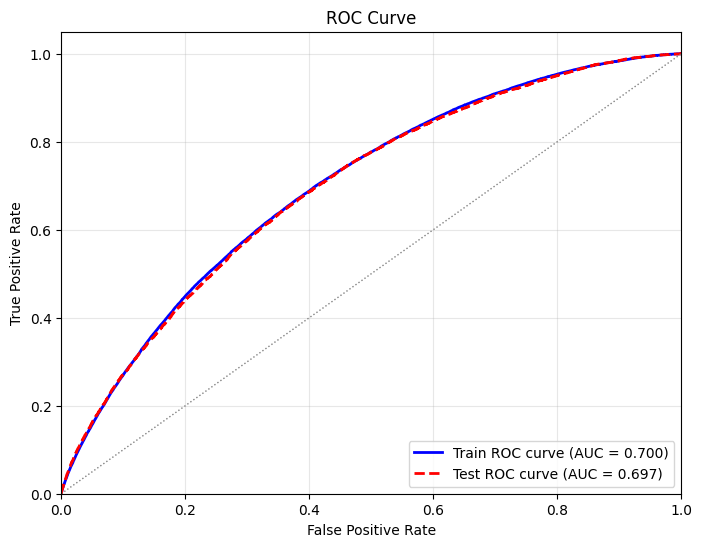

In [ ]:
# Compute ROC curve and AUC for train
fpr_train, tpr_train, _ = roc_curve(y_train, y_pred_train)
roc_auc_train = auc(fpr_train, tpr_train)

# Compute ROC curve and AUC for test
fpr_test, tpr_test, _ = roc_curve(y_test, y_pred_test)
roc_auc_test = auc(fpr_test, tpr_test)

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, color='blue', lw=2, label=f'Train ROC curve (AUC = {roc_auc_train:.3f})')
plt.plot(fpr_test, tpr_test, color='red', lw=2, linestyle='--', label=f'Test ROC curve (AUC = {roc_auc_test:.3f})')
plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle=':')  # random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

The results show that the model has a reasonable and fair performance. The ROC-AUC is around 70%, indicating that the model ranks defaulters higher than non-defaulters 70% of the time, which is decent for credit risk. By adjusting the probability threshold, it is possible to achieve an F1-Score of ~30% at a threshold of 0.60, where the balance between precision and recall is optimal.

Model metrics (Recall, Precision, F1, ROC-AUC) were calculated for different probability thresholds from 0.05 to 0.95. This threshold sweep illustrates the trade-offs between capturing as many defaults as possible (recall) and keeping predictions accurate (precision):

- **Recall**: Fraction of actual defaults that are correctly predicted.

At very low thresholds (0.05), recall = 1 → almost all observations are predicted as default, capturing all actual defaults.

At high thresholds (0.95), recall = 0 → almost no observations are predicted as default, missing all actual defaults.

- **Precision**: Fraction of predicted defaults that are actual defaults.

At low thresholds, precision is very low (~10%) because most predicted defaults are false positives.

Precision increases as the threshold rises, meaning predictions are more reliable, but fewer actual defaults are captured.

- **F1-Score**: Harmonic mean of precision and recall.

Peaks at thresholds where precision and recall are reasonably balanced. In this model, the peak occurs around threshold 0.60, giving ~0.30.

- **ROC-AUC**: Measures overall discrimination ability of the model, independent of threshold.

Around 0.70, which is considered decent for credit risk.

There is no sign of overfitting, since test results are similar to train results. The main limitation is low precision, even at thresholds where recall is high. Further improvements in feature engineering could help the model better discriminate between defaulters and non-defaulters.

## **Transforming probabilities into credit scores**

Once the model predicts probabilities of default (PD), these probabilities are converted into credit scores. This transformation has several benefits:

- Scores provide a more interpretable scale than raw probabilities. Higher scores correspond to lower default risk.

- The transformation is logarithmic, which increases granularity for very low and very high default probabilities.

- The scores are computed using the following formula:

$score = -\log{\frac{PD}{1-PD}} \times \frac{20}{\log{2}} + 600 -\log{50} \times \frac{20}{\log{2}}$

- Scores allow the creation of score bands, which can be used to define policies or risk thresholds.

In this analysis, predicted probabilities from the logistic regression model are converted into credit scores using this formula. We then plot the distributions of scores for both default and non-default individuals in the train and test sets.

These plots help:

- Visualize how well the model separates defaulters from non-defaulters.

- Identify thresholds or score bands that could guide risk-based decision making.

- Ensure that model behavior is consistent between train and test sets, checking for stability.

The resulting score distributions show that higher scores correspond to safer applicants, while lower scores correspond to riskier applicants. This provides a solid foundation for applying risk-based policies in practice.

In [ ]:
def convert_probabilities_to_scores(pd_array, pdo=20, base_score=600, base_odds=50):
    """
    Convert predicted probabilities of default to credit scores.

    Args:
        pd_array: array-like, predicted probabilities of default
        pdo: points to double the odds (default 20)
        base_score: reference score (default 600)
        base_odds: reference odds (non-default/default) (default 50)

    Returns:
        np.array of credit scores
    """
    odds = pd_array / (1 - pd_array)
    factor = pdo / np.log(2)
    offset = base_score - factor * np.log(base_odds)

    scores = offset - factor * np.log(odds)
    return scores

In [ ]:
def plot_distributions(scores, y_true, label=""):
    """
    Plot distributions of scores for Default (1) vs Non-Default (0)
    """
    plt.figure(figsize=(10,6))
    sns.kdeplot(scores[y_true == 0], label="Non-Default", fill=True)
    sns.kdeplot(scores[y_true == 1], label="Default", fill=True)
    plt.title(f"Score Distributions ({label})")
    plt.xlabel("Credit Score")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

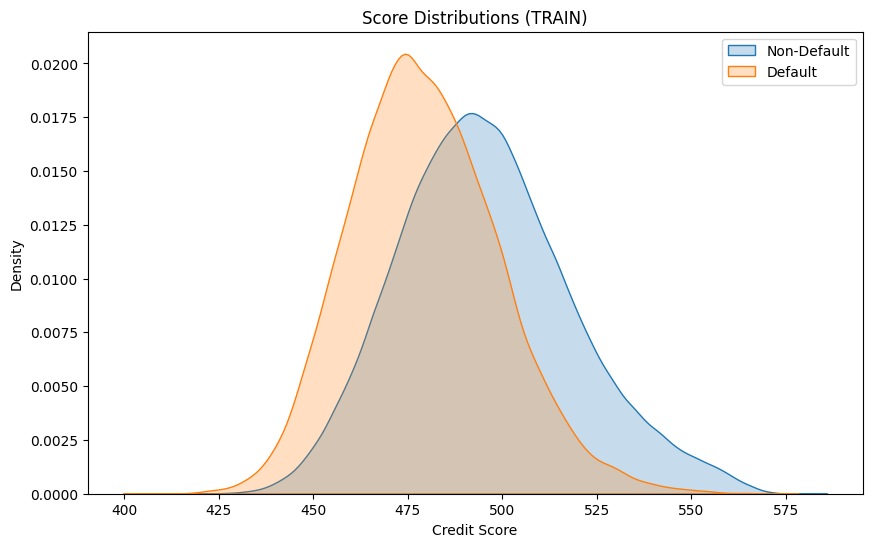

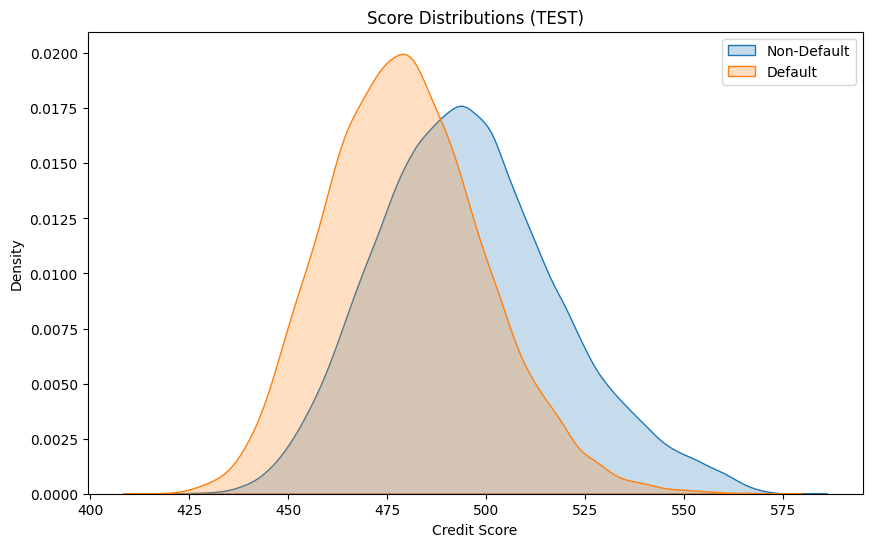

In [ ]:
# Convert probabilities to scores
scores_train = convert_probabilities_to_scores(y_pred_train)
scores_test = convert_probabilities_to_scores(y_pred_test)

# Plot distributions
plot_distributions(scores_train, y_train, label="TRAIN")
plot_distributions(scores_test, y_test, label="TEST")
